# Project 6: ACARS Detection Engineering

This notebook explores ACARS message data and develops a workflow for:

- Ingesting and normalizing ACARS messages
- Exploring message types and patterns
- Evaluating unusual timing behaviour
- Developing detection engineering use cases

**Status:** Exploratory analysis complete

## 1. Objective

Can timing between decoded ACARS records provide a stable and interpretable feature for anomaly analysis? This notebook builds a robust statistical baseline for decoded-record intervals and scores deviations from it, then examines whether the measurement unit is technically meaningful.

In [1]:
import pandas as pd

print("ACARS Detection Engineering: Project 6")
print("Environment ready.")

ACARS Detection Engineering: Project 6
Environment ready.


In [2]:
from pathlib import Path

project_root = Path.cwd()

print("Current working directory:")
print(project_root)

print("\nProject contents:")
for item in sorted(project_root.iterdir()):
    print(" -", item.name)

Current working directory:
/home/maria/acars-detection-engineering

Project contents:
 - .git
 - .gitignore
 - .ipynb_checkpoints
 - .venv
 - 01_acars_exploration.ipynb
 - README.md
 - data
 - detections
 - docs
 - notebooks
 - requirements.txt
 - src


In [3]:
data_dir = project_root / "data"

print("Data directory contents:")
for item in sorted(data_dir.rglob("*")):
    print(" -", item)

Data directory contents:
 - /home/maria/acars-detection-engineering/data/processed
 - /home/maria/acars-detection-engineering/data/raw
 - /home/maria/acars-detection-engineering/data/raw/sample.parquet


## Data Source Requirements

The project requires lawfully available, already-decoded aviation datalink data that can be analysed without intercepting live aircraft communications.

The preferred dataset should provide, where available:

- Timestamp
- Aircraft identifier or ICAO address
- Aircraft registration
- Flight number
- ACARS message label
- Message text
- Message source or transport type
- A sufficiently large historical sample for behavioural analysis

The dataset must also permit non-commercial research and portfolio use.

## Primary Dataset

This project will use the public `vdliq-data` dataset from the vdliq feeder network as its initial data source.

The dataset contains public-safe, already-decoded VDL2/ACARS application messages stored in daily Parquet files.

Relevant fields include:

- `timestamp`
- `icaoHex`
- `tail`
- `flightNumber`
- `label`
- `mode`
- `sourceType`
- `text`

Using a reproducible public dataset allows the detection pipeline to be tested and repeated without requiring access to a live radio receiver or proprietary aviation data feed.

The dataset will be used only according to its published licence and attribution requirements.

## 2. Dataset and Initial Inspection

Loading the raw ACARS observations from the Parquet file and inspecting shape, columns, and a sample of records before any cleaning.

In [4]:
data_path = project_root / "data" / "raw" / "sample.parquet"

real_df = pd.read_parquet(data_path)

print("Dataset shape:", real_df.shape)
print("\nColumns:")
print(real_df.columns.tolist())

real_df.head()

Dataset shape: (200, 20)

Columns:
['timestamp', 'icaoHex', 'fromHex', 'toHex', 'tail', 'flightNumber', 'label', 'blockId', 'msgNum', 'frequency', 'level', 'mode', 'source', 'sourceType', 'text', 'feederId', 'id', 'uuid', 'station', 'raw']


,timestamp,icaoHex,fromHex,toHex,tail,flightNumber,label,blockId,msgNum,frequency,level,mode,source,sourceType,text,feederId,id,uuid,station,raw
0,1.782777e+09,NaN,NaN,NaN,NaN,NaN,SQ,NaN,NaN,131.55,-20.8,2,vdliq,ACARS,02XAPBIKPBI12650N08013WV136975/ARINC,JS-KPBI-ACARS,28045,11ecce92-1c47-43c3-91b3-d2506bb18b46,"{""ident"":""JS-KPBI-ACARS"",""lat"":null,""lng"":null}","{""timestamp"":1782777317.214666,""station_id"":""J..."
1,1.782777e+09,NaN,NaN,NaN,N325US,NaN,H1,Z,NaN,131.55,-21.2,2,vdliq,ACARS,.ATLYDDL 292356\r\nDFD\r\nAN .N325US/FI NW0866...,JS-KPBI-ACARS,28046,6ea12f72-adcf-4a0b-98b0-f4bc63f5bea3,"{""ident"":""JS-KPBI-ACARS"",""lat"":null,""lng"":null}","{""timestamp"":1782777372.678457,""station_id"":""J..."
2,1.782778e+09,NaN,NaN,NaN,G-TUIO,NaN,:;,G,NaN,131.55,-20.5,2,vdliq,ACARS,130025,JS-KPBI-ACARS,28047,58dffcbc-7eb3-4a14-a087-5ed074b9cc7d,"{""ident"":""JS-KPBI-ACARS"",""lat"":null,""lng"":null}","{""timestamp"":1782777522.2707,""station_id"":""JS-..."
3,1.782778e+09,NaN,NaN,NaN,N341NB,NW1638,4L,3,M44A,131.55,-6.1,2,vdliq,ACARS,29234L KPBI KJFK7\r\n/FN 1638\r\n/ENG 1 RUN 23...,JS-KPBI-ACARS,28048,18db5c99-7710-4ed5-b6e1-ff4d00fd097c,"{""ident"":""JS-KPBI-ACARS"",""lat"":null,""lng"":null}","{""timestamp"":1782777566.387947,""station_id"":""J..."
4,1.782778e+09,NaN,NaN,NaN,N341NB,NW1638,H1,4,D35C,131.55,-3.0,2,vdliq,ACARS,",017,008,000,100,2/E90272,0698,13,149,095,000,...",JS-KPBI-ACARS,28049,1d0a91b4-1a39-4293-9314-ac02631ee5a2,"{""ident"":""JS-KPBI-ACARS"",""lat"":null,""lng"":null}","{""timestamp"":1782777572.361148,""station_id"":""J..."


In [5]:
print("Dataset information:")
real_df.info()

print("\n\nMissing values per column:")
print(real_df.isna().sum())

print("\n\nUnique values in source/category fields:")
for column in ["label", "mode", "sourceType", "public_category"]:
    if column in real_df.columns:
        print(f"\n{column}:")
        print(real_df[column].value_counts().head(20))

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     200 non-null    float64
 1   icaoHex       127 non-null    str    
 2   fromHex       127 non-null    str    
 3   toHex         127 non-null    str    
 4   tail          104 non-null    str    
 5   flightNumber  97 non-null     str    
 6   label         142 non-null    str    
 7   blockId       104 non-null    str    
 8   msgNum        97 non-null     str    
 9   frequency     200 non-null    str    
 10  level         200 non-null    str    
 11  mode          142 non-null    str    
 12  source        200 non-null    str    
 13  sourceType    200 non-null    str    
 14  text          142 non-null    str    
 15  feederId      200 non-null    str    
 16  id            200 non-null    str    
 17  uuid          200 non-null    str    
 18  station       200 no

In [6]:
decoded_messages = real_df[real_df["text"].notna()].copy()

print(f"Total records: {len(real_df)}")
print(f"Records with decoded text: {len(decoded_messages)}")

decoded_messages[
    [
        "timestamp",
        "icaoHex",
        "tail",
        "flightNumber",
        "label",
        "sourceType",
        "text"
    ]
].head(10)

Total records: 200
Records with decoded text: 142


,timestamp,icaoHex,tail,flightNumber,label,sourceType,text
0,1.782777e+09,NaN,NaN,NaN,SQ,ACARS,02XAPBIKPBI12650N08013WV136975/ARINC
1,1.782777e+09,NaN,N325US,NaN,H1,ACARS,.ATLYDDL 292356\r\nDFD\r\nAN .N325US/FI NW0866...
2,1.782778e+09,NaN,G-TUIO,NaN,:;,ACARS,130025
3,1.782778e+09,NaN,N341NB,NW1638,4L,ACARS,29234L KPBI KJFK7\r\n/FN 1638\r\n/ENG 1 RUN 23...
4,1.782778e+09,NaN,N341NB,NW1638,H1,ACARS,",017,008,000,100,2/E90272,0698,13,149,095,000,..."
5,1.782778e+09,NaN,N341NB,NW1638,10,ACARS,292310 KPBI KJFK6\r\n1638235901822342233823342...
7,1.782778e+09,NaN,N341NB,NaN,H1,ACARS,POS/RFLENDS.PYSTN.KALDA.ZJAAY.BYSEL.HOWYU.ACTU...
8,1.782778e+09,NaN,N341NB,NW1638,H1,ACARS,"177,35,-0082,2/1E0240,0645,13,151,095,000,004,..."
9,1.782778e+09,NaN,N341NB,NaN,:;,ACARS,130025
10,1.782778e+09,NaN,N341NB,NW1638,H1,ACARS,"RESPOS/AK6A,071A8C6"


In [7]:
for label in decoded_messages["label"].dropna().value_counts().head(10).index:
    print(f"\n{'=' * 70}")
    print(f"LABEL: {label}")
    print(f"{'=' * 70}")

    samples = decoded_messages[
        decoded_messages["label"] == label
    ][["sourceType", "flightNumber", "tail", "text"]].head(3)

    for _, row in samples.iterrows():
        print("\nSource type:", row["sourceType"])
        print("Flight:", row["flightNumber"])
        print("Aircraft:", row["tail"])
        print("Message:")
        print(row["text"])


LABEL: H1

Source type: ACARS
Flight: nan
Aircraft: N325US
Message:
.ATLYDDL 292356
DFD
AN .N325US/FI NW0866/GL PBI/MA 995I
- #DFREQ19


Source type: ACARS
Flight: NW1638
Aircraft: N341NB
Message:
,017,008,000,100,2/E90272,0698,13,149,095,000,004,0/N90272,0701,12,135,095,000,004,0/E00285,0685,13,152,095,000,004,0/N00290,0704,12,142,095,000,004,0/S00535,2150,029,-02,177,33,-0061,2/T00543,2160,030,-02,

Source type: ACARS
Flight: nan
Aircraft: N341NB
Message:
POS/RFLENDS.PYSTN.KALDA.ZJAAY.BYSEL.HOWYU.ACTUP.SIE.BOTON.HOGGS.PANZE.KARRS.CAMRN/SN6AD5FF




LABEL: SQ

Source type: ACARS
Flight: nan
Aircraft: nan
Message:
02XAPBIKPBI12650N08013WV136975/ARINC

Source type: ACARS
Flight: nan
Aircraft: nan
Message:
02XAPBIKPBI12650N08013WV136975/ARINC

Source type: ACARS
Flight: nan
Aircraft: nan
Message:
02XAPBIKPBI12650N08013WV136975/ARINC

LABEL: _d

Source type: VDL2
Flight: B60368
Aircraft: N595JB
Message:


Source type: VDL2
Flight: AA1246
Aircraft: N339PL
Message:


Source type: VDL2
Flig

In [8]:
text_missing = real_df["text"].isna().sum()

text_empty = (
    real_df["text"]
    .fillna("")
    .str.strip()
    .eq("")
    .sum()
)

print("Total records:", len(real_df))
print("Records where text is NaN:", text_missing)
print("Records where text is empty or whitespace:", text_empty)

empty_text_records = real_df[
    real_df["text"].fillna("").str.strip().eq("")
]

print("\nSource types for empty-text records:")
print(empty_text_records["sourceType"].value_counts())

print("\nLabels for empty-text records:")
print(empty_text_records["label"].value_counts(dropna=False))

Total records: 200
Records where text is NaN: 58
Records where text is empty or whitespace: 73

Source types for empty-text records:
sourceType
VDL2    73
Name: count, dtype: int64

Labels for empty-text records:
label
NaN    58
_d     11
Q0      3
45      1
Name: count, dtype: int64


### Data Provenance

The sample used in this analysis was downloaded from the public VDLiq
dataset. The following checks record the local file used for the analysis
and the source metadata present in the dataset.

In [9]:
print("File:", data_path)
print("Exists:", data_path.exists())
print("Size (bytes):", data_path.stat().st_size)
print("Modified:", pd.Timestamp(data_path.stat().st_mtime, unit="s"))

File: /home/maria/acars-detection-engineering/data/raw/sample.parquet
Exists: True
Size (bytes): 36200
Modified: 2026-08-29 13:24:28.563180923


In [10]:
print("Shape:", real_df.shape)

print("\nColumns:")
print(real_df.columns.tolist())

print("\nFirst 5 rows:")
display(real_df.head())

print("\nSource values:")
print(real_df["source"].value_counts(dropna=False))

print("\nSource type values:")
print(real_df["sourceType"].value_counts(dropna=False))

Shape: (200, 20)

Columns:
['timestamp', 'icaoHex', 'fromHex', 'toHex', 'tail', 'flightNumber', 'label', 'blockId', 'msgNum', 'frequency', 'level', 'mode', 'source', 'sourceType', 'text', 'feederId', 'id', 'uuid', 'station', 'raw']

First 5 rows:


,timestamp,icaoHex,fromHex,toHex,tail,flightNumber,label,blockId,msgNum,frequency,level,mode,source,sourceType,text,feederId,id,uuid,station,raw
0,1.782777e+09,NaN,NaN,NaN,NaN,NaN,SQ,NaN,NaN,131.55,-20.8,2,vdliq,ACARS,02XAPBIKPBI12650N08013WV136975/ARINC,JS-KPBI-ACARS,28045,11ecce92-1c47-43c3-91b3-d2506bb18b46,"{""ident"":""JS-KPBI-ACARS"",""lat"":null,""lng"":null}","{""timestamp"":1782777317.214666,""station_id"":""J..."
1,1.782777e+09,NaN,NaN,NaN,N325US,NaN,H1,Z,NaN,131.55,-21.2,2,vdliq,ACARS,.ATLYDDL 292356\r\nDFD\r\nAN .N325US/FI NW0866...,JS-KPBI-ACARS,28046,6ea12f72-adcf-4a0b-98b0-f4bc63f5bea3,"{""ident"":""JS-KPBI-ACARS"",""lat"":null,""lng"":null}","{""timestamp"":1782777372.678457,""station_id"":""J..."
2,1.782778e+09,NaN,NaN,NaN,G-TUIO,NaN,:;,G,NaN,131.55,-20.5,2,vdliq,ACARS,130025,JS-KPBI-ACARS,28047,58dffcbc-7eb3-4a14-a087-5ed074b9cc7d,"{""ident"":""JS-KPBI-ACARS"",""lat"":null,""lng"":null}","{""timestamp"":1782777522.2707,""station_id"":""JS-..."
3,1.782778e+09,NaN,NaN,NaN,N341NB,NW1638,4L,3,M44A,131.55,-6.1,2,vdliq,ACARS,29234L KPBI KJFK7\r\n/FN 1638\r\n/ENG 1 RUN 23...,JS-KPBI-ACARS,28048,18db5c99-7710-4ed5-b6e1-ff4d00fd097c,"{""ident"":""JS-KPBI-ACARS"",""lat"":null,""lng"":null}","{""timestamp"":1782777566.387947,""station_id"":""J..."
4,1.782778e+09,NaN,NaN,NaN,N341NB,NW1638,H1,4,D35C,131.55,-3.0,2,vdliq,ACARS,",017,008,000,100,2/E90272,0698,13,149,095,000,...",JS-KPBI-ACARS,28049,1d0a91b4-1a39-4293-9314-ac02631ee5a2,"{""ident"":""JS-KPBI-ACARS"",""lat"":null,""lng"":null}","{""timestamp"":1782777572.361148,""station_id"":""J..."



Source values:
source
vdliq    200
Name: count, dtype: int64

Source type values:
sourceType
VDL2     127
ACARS     73
Name: count, dtype: int64


In [11]:
display(
    real_df[
        [
            "timestamp",
            "icaoHex",
            "tail",
            "flightNumber",
            "label",
            "source",
            "sourceType"
        ]
    ].head(20)
)

,timestamp,icaoHex,tail,flightNumber,label,source,sourceType
0,1.782777e+09,NaN,NaN,NaN,SQ,vdliq,ACARS
1,1.782777e+09,NaN,N325US,NaN,H1,vdliq,ACARS
2,1.782778e+09,NaN,G-TUIO,NaN,:;,vdliq,ACARS
3,1.782778e+09,NaN,N341NB,NW1638,4L,vdliq,ACARS
4,1.782778e+09,NaN,N341NB,NW1638,H1,vdliq,ACARS
5,1.782778e+09,NaN,N341NB,NW1638,10,vdliq,ACARS
6,1.782778e+09,a7f6f6,NaN,NaN,NaN,vdliq,VDL2
7,1.782778e+09,NaN,N341NB,NaN,H1,vdliq,ACARS
8,1.782778e+09,NaN,N341NB,NW1638,H1,vdliq,ACARS
9,1.782778e+09,NaN,N341NB,NaN,:;,vdliq,ACARS


## 3. Data Cleaning and Normalization

Dropping records with no usable message text, normalizing field names into an analysis-friendly schema, and converting timestamps to timezone-aware UTC.

In [12]:
clean_messages = real_df[
    real_df["text"].notna()
    & real_df["text"].astype(str).str.strip().ne("")
].copy()

clean_messages["text"] = clean_messages["text"].str.strip()

print("Original records:", len(real_df))
print("Usable message records:", len(clean_messages))
print("Records excluded:", len(real_df) - len(clean_messages))

print("\nUsable records by source type:")
print(clean_messages["sourceType"].value_counts())

print("\nUsable records by label:")
print(clean_messages["label"].value_counts().head(20))

Original records: 200
Usable message records: 127
Records excluded: 73

Usable records by source type:
sourceType
ACARS    73
VDL2     54
Name: count, dtype: int64

Usable records by label:
label
H1    64
SQ    38
21     5
22     4
:;     2
10     2
BA     2
4L     1
31     1
AA     1
A6     1
30     1
43     1
3B     1
3J     1
B9     1
SA     1
Name: count, dtype: int64


In [13]:
normalized_df = clean_messages.copy()

normalized_df = normalized_df.rename(
    columns={
        "icaoHex": "aircraft_id",
        "tail": "registration",
        "flightNumber": "flight_id",
        "text": "raw_message"
    }
)

normalized_df["timestamp"] = pd.to_datetime(
    normalized_df["timestamp"],
    unit="s",
    utc=True
)

normalized_df["message_type"] = normalized_df["label"]

normalized_df["origin"] = None
normalized_df["destination"] = None

normalized_df = normalized_df[
    [
        "timestamp",
        "aircraft_id",
        "registration",
        "flight_id",
        "label",
        "message_type",
        "origin",
        "destination",
        "raw_message",
        "source",
        "sourceType",
        "frequency",
        "msgNum",
        "blockId"
    ]
]

normalized_df.head()

,timestamp,aircraft_id,registration,flight_id,label,message_type,origin,destination,raw_message,source,sourceType,frequency,msgNum,blockId
0,2026-06-29 23:55:17.214665890+00:00,NaN,NaN,NaN,SQ,SQ,None,None,02XAPBIKPBI12650N08013WV136975/ARINC,vdliq,ACARS,131.55,NaN,NaN
1,2026-06-29 23:56:12.678457022+00:00,NaN,N325US,NaN,H1,H1,None,None,.ATLYDDL 292356\r\nDFD\r\nAN .N325US/FI NW0866...,vdliq,ACARS,131.55,NaN,Z
2,2026-06-29 23:58:42.270699978+00:00,NaN,G-TUIO,NaN,:;,:;,None,None,130025,vdliq,ACARS,131.55,NaN,G
3,2026-06-29 23:59:26.387947083+00:00,NaN,N341NB,NW1638,4L,4L,None,None,29234L KPBI KJFK7\r\n/FN 1638\r\n/ENG 1 RUN 23...,vdliq,ACARS,131.55,M44A,3
4,2026-06-29 23:59:32.361148119+00:00,NaN,N341NB,NW1638,H1,H1,None,None,",017,008,000,100,2/E90272,0698,13,149,095,000,...",vdliq,ACARS,131.55,D35C,4


In [14]:
print("Normalized dataset shape:", normalized_df.shape)

print("\nData types:")
print(normalized_df.dtypes)

print("\nMissing values:")
print(normalized_df.isna().sum())

print("\nPreview of unique message types:")
print(normalized_df["message_type"].value_counts())

Normalized dataset shape: (127, 14)

Data types:
timestamp       datetime64[ns, UTC]
aircraft_id                     str
registration                    str
flight_id                       str
label                           str
message_type                    str
origin                       object
destination                  object
raw_message                     str
source                          str
sourceType                      str
frequency                       str
msgNum                          str
blockId                         str
dtype: object

Missing values:
timestamp         0
aircraft_id      73
registration     38
flight_id        45
label             0
message_type      0
origin          127
destination     127
raw_message       0
source            0
sourceType        0
frequency         0
msgNum           45
blockId          38
dtype: int64

Preview of unique message types:
message_type
H1    64
SQ    38
21     5
22     4
:;     2
10     2
BA     2
4L     1
31  

In [15]:
print("Message count by label:")
print(normalized_df["message_type"].value_counts())

print("\nTop aircraft/registrations by message count:")
print(
    normalized_df.groupby("registration")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop flights by message count:")
print(
    normalized_df.groupby("flight_id")
    .size()
    .sort_values(ascending=False)
    .head(10)
)

Message count by label:
message_type
H1    64
SQ    38
21     5
22     4
:;     2
10     2
BA     2
4L     1
31     1
AA     1
A6     1
30     1
43     1
3B     1
3J     1
B9     1
SA     1
Name: count, dtype: int64

Top aircraft/registrations by message count:
registration
N341NB    20
N261BZ    15
N635FR    14
N464UP     9
N378FR     6
G-TUIO     4
N339PL     3
N809VL     3
N3307J     3
N595JB     3
dtype: int64

Top flights by message count:
flight_id
NW1638    18
MX0263    15
F92582    14
UP1333     9
F92959     6
AA1246     3
XP0223     3
B62322     3
B60368     3
F92249     2
dtype: int64


## 4. Initial Timing Exploration

The first timing feature measures the elapsed time between consecutive ACARS messages from the same aircraft. This provides an initial view of message cadence and timing variation, without yet distinguishing between different message types.

In [16]:
aircraft_focus = "N341NB"

aircraft_messages = (
    normalized_df[
        normalized_df["registration"] == aircraft_focus
    ]
    .sort_values("timestamp")
    .copy()
)

print(f"Messages for {aircraft_focus}: {len(aircraft_messages)}")

aircraft_messages[
    [
        "timestamp",
        "registration",
        "flight_id",
        "message_type",
        "raw_message"
    ]
]

Messages for N341NB: 20


,timestamp,registration,flight_id,message_type,raw_message
3,2026-06-29 23:59:26.387947083+00:00,N341NB,NW1638,4L,29234L KPBI KJFK7\r\n/FN 1638\r\n/ENG 1 RUN 23...
4,2026-06-29 23:59:32.361148119+00:00,N341NB,NW1638,H1,",017,008,000,100,2/E90272,0698,13,149,095,000,..."
5,2026-06-29 23:59:39.017147064+00:00,N341NB,NW1638,10,292310 KPBI KJFK6\r\n1638235901822342233823342...
7,2026-06-29 23:59:45.158271074+00:00,N341NB,NaN,H1,POS/RFLENDS.PYSTN.KALDA.ZJAAY.BYSEL.HOWYU.ACTU...
8,2026-06-29 23:59:46.185273886+00:00,N341NB,NW1638,H1,"177,35,-0082,2/1E0240,0645,13,151,095,000,004,..."
9,2026-06-29 23:59:51.475965023+00:00,N341NB,NaN,:;,130025
10,2026-06-29 23:59:52.585673094+00:00,N341NB,NW1638,H1,"RESPOS/AK6A,071A8C6"
11,2026-06-29 23:59:57.876271009+00:00,N341NB,NW1638,H1,"23,-0080,2/2V0305,0303,00000,00000,685,685,682..."
12,2026-06-30 00:00:19.039120913+00:00,N341NB,NW1638,H1,"A319,085015,1,1,TB000000/REP207,00,00,4/CCN341..."
13,2026-06-30 00:00:32.009679079+00:00,N341NB,NW1638,H1,"0,034,146,----,025,014/V111,17,326,330,03,02,0..."


In [17]:
timeline_view = aircraft_messages[
    [
        "timestamp",
        "flight_id",
        "message_type",
        "raw_message"
    ]
].copy()

timeline_view["message_preview"] = (
    timeline_view["raw_message"]
    .str.replace(r"[\r\n]+", " ", regex=True)
    .str.slice(0, 70)
)

timeline_view = timeline_view[
    [
        "timestamp",
        "flight_id",
        "message_type",
        "message_preview"
    ]
]

timeline_view

,timestamp,flight_id,message_type,message_preview
3,2026-06-29 23:59:26.387947083+00:00,NW1638,4L,29234L KPBI KJFK7 /FN 1638 /ENG 1 RUN 234613/E...
4,2026-06-29 23:59:32.361148119+00:00,NW1638,H1,",017,008,000,100,2/E90272,0698,13,149,095,000,..."
5,2026-06-29 23:59:39.017147064+00:00,NW1638,10,292310 KPBI KJFK6 1638235901822342233823342340...
7,2026-06-29 23:59:45.158271074+00:00,NaN,H1,POS/RFLENDS.PYSTN.KALDA.ZJAAY.BYSEL.HOWYU.ACTU...
8,2026-06-29 23:59:46.185273886+00:00,NW1638,H1,"177,35,-0082,2/1E0240,0645,13,151,095,000,004,..."
9,2026-06-29 23:59:51.475965023+00:00,NaN,:;,130025
10,2026-06-29 23:59:52.585673094+00:00,NW1638,H1,"RESPOS/AK6A,071A8C6"
11,2026-06-29 23:59:57.876271009+00:00,NW1638,H1,"23,-0080,2/2V0305,0303,00000,00000,685,685,682..."
12,2026-06-30 00:00:19.039120913+00:00,NW1638,H1,"A319,085015,1,1,TB000000/REP207,00,00,4/CCN341..."
13,2026-06-30 00:00:32.009679079+00:00,NW1638,H1,"0,034,146,----,025,014/V111,17,326,330,03,02,0..."


In [18]:
aircraft_messages = aircraft_messages.sort_values("timestamp").copy()

aircraft_messages["time_since_previous"] = (
    aircraft_messages["timestamp"]
    .diff()
    .dt.total_seconds()
)

aircraft_messages[
    [
        "timestamp",
        "flight_id",
        "message_type",
        "time_since_previous"
    ]
]

,timestamp,flight_id,message_type,time_since_previous
3,2026-06-29 23:59:26.387947083+00:00,NW1638,4L,NaN
4,2026-06-29 23:59:32.361148119+00:00,NW1638,H1,5.973201
5,2026-06-29 23:59:39.017147064+00:00,NW1638,10,6.655999
7,2026-06-29 23:59:45.158271074+00:00,NaN,H1,6.141124
8,2026-06-29 23:59:46.185273886+00:00,NW1638,H1,1.027003
9,2026-06-29 23:59:51.475965023+00:00,NaN,:;,5.290691
10,2026-06-29 23:59:52.585673094+00:00,NW1638,H1,1.109708
11,2026-06-29 23:59:57.876271009+00:00,NW1638,H1,5.290598
12,2026-06-30 00:00:19.039120913+00:00,NW1638,H1,21.162850
13,2026-06-30 00:00:32.009679079+00:00,NW1638,H1,12.970558


In [19]:
timing_stats = aircraft_messages["time_since_previous"].describe()

print("Message timing statistics (seconds):")
print(timing_stats)

print("\nShortest observed intervals:")
print(
    aircraft_messages[
        [
            "timestamp",
            "flight_id",
            "message_type",
            "time_since_previous"
        ]
    ]
    .sort_values("time_since_previous")
    .head(5)
)

Message timing statistics (seconds):
count    19.000000
mean      7.477909
std       4.820327
min       1.027003
25%       5.846694
50%       6.655999
75%       6.997280
max      21.162850
Name: time_since_previous, dtype: float64

Shortest observed intervals:
                             timestamp flight_id message_type  \
8  2026-06-29 23:59:46.185273886+00:00    NW1638           H1   
10 2026-06-29 23:59:52.585673094+00:00    NW1638           H1   
11 2026-06-29 23:59:57.876271009+00:00    NW1638           H1   
9  2026-06-29 23:59:51.475965023+00:00       NaN           :;   
18 2026-06-30 00:01:13.993369102+00:00    NW1638           H1   

    time_since_previous  
8              1.027003  
10             1.109708  
11             5.290598  
9              5.290691  
18             5.805603  


In [20]:
timing_df = normalized_df.copy()

timing_df = timing_df[
    timing_df["registration"].notna()
].sort_values(
    ["registration", "timestamp"]
)

timing_df["time_since_previous"] = (
    timing_df
    .groupby("registration")["timestamp"]
    .diff()
    .dt.total_seconds()
)

timing_df[
    [
        "timestamp",
        "registration",
        "flight_id",
        "message_type",
        "time_since_previous"
    ]
].head(20)

,timestamp,registration,flight_id,message_type,time_since_previous
2,2026-06-29 23:58:42.270699978+00:00,G-TUIO,NaN,:;,NaN
36,2026-06-30 00:04:11.145317078+00:00,G-TUIO,NaN,H1,328.874617
51,2026-06-30 00:11:57.748028040+00:00,G-TUIO,NaN,AA,466.602711
52,2026-06-30 00:12:42.291718006+00:00,G-TUIO,NaN,A6,44.543690
57,2026-06-30 00:22:49.391087055+00:00,N261BZ,MX0263,H1,NaN
59,2026-06-30 00:22:51.053950071+00:00,N261BZ,MX0263,H1,1.662863
60,2026-06-30 00:22:53.963365078+00:00,N261BZ,MX0263,H1,2.909415
63,2026-06-30 00:22:56.547746897+00:00,N261BZ,MX0263,H1,2.584382
64,2026-06-30 00:22:58.377253056+00:00,N261BZ,MX0263,H1,1.829506
66,2026-06-30 00:23:09.643557072+00:00,N261BZ,MX0263,H1,11.266304


In [21]:
aircraft_timing_stats = (
    timing_df
    .groupby("registration")["time_since_previous"]
    .agg(
        message_intervals="count",
        mean_interval_seconds="mean",
        median_interval_seconds="median",
        min_interval_seconds="min",
        max_interval_seconds="max"
    )
    .sort_values("message_intervals", ascending=False)
)

aircraft_timing_stats

,message_intervals,mean_interval_seconds,median_interval_seconds,min_interval_seconds,max_interval_seconds
registration,,,,,
N341NB,19,7.477909,6.655999,1.027003,21.162850
N261BZ,14,2.589564,1.743902,1.361951,11.266304
N635FR,13,2.801777,1.221648,0.755121,21.933859
N464UP,8,57.447768,31.545442,1.219846,160.313331
N378FR,5,95.914103,62.464109,5.543905,300.540490
G-TUIO,3,280.007006,328.874617,44.543690,466.602711
N339PL,2,18.816418,18.816418,18.595137,19.037699
N809VL,2,7.321292,7.321292,6.564505,8.078079
N3307J,2,3.961597,3.961597,1.821570,6.101625


In [22]:
minimum_intervals = 5

baseline_candidates = aircraft_timing_stats[
    aircraft_timing_stats["message_intervals"] >= minimum_intervals
].copy()

print(
    f"Aircraft with at least {minimum_intervals} "
    "observed message intervals:"
)

print(baseline_candidates)

Aircraft with at least 5 observed message intervals:
              message_intervals  mean_interval_seconds  \
registration                                             
N341NB                       19               7.477909   
N261BZ                       14               2.589564   
N635FR                       13               2.801777   
N464UP                        8              57.447768   
N378FR                        5              95.914103   

              median_interval_seconds  min_interval_seconds  \
registration                                                  
N341NB                       6.655999              1.027003   
N261BZ                       1.743902              1.361951   
N635FR                       1.221648              0.755121   
N464UP                      31.545442              1.219846   
N378FR                      62.464109              5.543905   

              max_interval_seconds  
registration                        
N341NB                  

In [23]:
baseline_features = (
    timing_df
    .groupby("registration")["time_since_previous"]
    .agg(
        interval_count="count",
        median_interval="median",
        mean_interval="mean",
        std_interval="std"
    )
)

baseline_features = baseline_features[
    baseline_features["interval_count"] >= 5
]

baseline_features

,interval_count,median_interval,mean_interval,std_interval
registration,,,,
N261BZ,14,1.743902,2.589564,2.551163
N341NB,19,6.655999,7.477909,4.820327
N378FR,5,62.464109,95.914103,121.684857
N464UP,8,31.545442,57.447768,62.987524
N635FR,13,1.221648,2.801777,5.756745


## 5. Initial Robust Baseline

To reduce the influence of unusually large or small timing gaps, the initial baseline uses the median and median absolute deviation (MAD) of message intervals for each aircraft registration.

This is an exploratory baseline rather than the final methodology. At this stage, intervals from different ACARS message types are still being evaluated together.

In [24]:
def median_absolute_deviation(series):
    median = series.median()
    return (series - median).abs().median()


robust_baseline = (
    timing_df
    .groupby("registration")["time_since_previous"]
    .agg(
        interval_count="count",
        median_interval="median",
        mad_interval=median_absolute_deviation
    )
)

robust_baseline = robust_baseline[
    robust_baseline["interval_count"] >= 5
]

robust_baseline

,interval_count,median_interval,mad_interval
registration,,,
N261BZ,14,1.743902,0.290602
N341NB,19,6.655999,0.682798
N378FR,5,62.464109,55.975366
N464UP,8,31.545442,29.799080
N635FR,13,1.221648,0.303338


In [25]:
timing_scored = timing_df.copy()

timing_scored["median_interval"] = (
    timing_scored["registration"]
    .map(robust_baseline["median_interval"])
)

timing_scored["mad_interval"] = (
    timing_scored["registration"]
    .map(robust_baseline["mad_interval"])
)

timing_scored["absolute_deviation"] = (
    timing_scored["time_since_previous"]
    - timing_scored["median_interval"]
).abs()

timing_scored["timing_deviation_score"] = (
    timing_scored["absolute_deviation"]
    / timing_scored["mad_interval"]
)

timing_scored[
    [
        "timestamp",
        "registration",
        "flight_id",
        "message_type",
        "time_since_previous",
        "median_interval",
        "mad_interval",
        "absolute_deviation",
        "timing_deviation_score"
    ]
].head(20)

,timestamp,registration,flight_id,message_type,time_since_previous,median_interval,mad_interval,absolute_deviation,timing_deviation_score
2,2026-06-29 23:58:42.270699978+00:00,G-TUIO,NaN,:;,NaN,NaN,NaN,NaN,NaN
36,2026-06-30 00:04:11.145317078+00:00,G-TUIO,NaN,H1,328.874617,NaN,NaN,NaN,NaN
51,2026-06-30 00:11:57.748028040+00:00,G-TUIO,NaN,AA,466.602711,NaN,NaN,NaN,NaN
52,2026-06-30 00:12:42.291718006+00:00,G-TUIO,NaN,A6,44.543690,NaN,NaN,NaN,NaN
57,2026-06-30 00:22:49.391087055+00:00,N261BZ,MX0263,H1,NaN,1.743902,0.290602,NaN,NaN
59,2026-06-30 00:22:51.053950071+00:00,N261BZ,MX0263,H1,1.662863,1.743902,0.290602,0.081039,0.278866
60,2026-06-30 00:22:53.963365078+00:00,N261BZ,MX0263,H1,2.909415,1.743902,0.290602,1.165513,4.010687
63,2026-06-30 00:22:56.547746897+00:00,N261BZ,MX0263,H1,2.584382,1.743902,0.290602,0.840480,2.892204
64,2026-06-30 00:22:58.377253056+00:00,N261BZ,MX0263,H1,1.829506,1.743902,0.290602,0.085604,0.294576
66,2026-06-30 00:23:09.643557072+00:00,N261BZ,MX0263,H1,11.266304,1.743902,0.290602,9.522402,32.767865


In [26]:
high_deviation_records = (
    timing_scored
    .dropna(subset=["timing_deviation_score"])
    .sort_values("timing_deviation_score", ascending=False)
)

high_deviation_records[
    [
        "timestamp",
        "registration",
        "flight_id",
        "message_type",
        "time_since_previous",
        "median_interval",
        "mad_interval",
        "absolute_deviation",
        "timing_deviation_score",
        "raw_message"
    ]
].head(15)

,timestamp,registration,flight_id,message_type,time_since_previous,median_interval,mad_interval,absolute_deviation,timing_deviation_score,raw_message
126,2026-06-30 00:54:10.527805090+00:00,N635FR,F92582,H1,21.933859,1.221648,0.303338,20.712211,68.281007,"A321,029197,1,1,TB000000/REP004,84,01,4/CCN635..."
66,2026-06-30 00:23:09.643557072+00:00,N261BZ,MX0263,H1,11.266304,1.743902,0.290602,9.522402,32.767865,"R641V0106,180300,, N261BZ,5318410-07,737110,73..."
12,2026-06-30 00:00:19.039120913+00:00,N341NB,NW1638,H1,21.162850,6.655999,0.682798,14.506851,21.246185,"A319,085015,1,1,TB000000/REP207,00,00,4/CCN341..."
17,2026-06-30 00:01:08.187766075+00:00,N341NB,NW1638,H1,17.234247,6.655999,0.682798,10.578248,15.492502,FLR/FR26062923590023730005NO CIDS 2 DATA\r/IDCFDS
13,2026-06-30 00:00:32.009679079+00:00,N341NB,NW1638,H1,12.970558,6.655999,0.682798,6.314559,9.248065,"0,034,146,----,025,014/V111,17,326,330,03,02,0..."
8,2026-06-29 23:59:46.185273886+00:00,N341NB,NW1638,H1,1.027003,6.655999,0.682798,5.628996,8.244015,"177,35,-0082,2/1E0240,0645,13,151,095,000,004,..."
10,2026-06-29 23:59:52.585673094+00:00,N341NB,NW1638,H1,1.109708,6.655999,0.682798,5.546291,8.122888,"RESPOS/AK6A,071A8C6"
174,2026-06-30 01:05:10.504455090+00:00,N464UP,UP1333,H1,160.313331,31.545442,29.799080,128.767889,4.321203,USADCXA.AT1.N464UP62061149008FF2
84,2026-06-30 00:27:51.088361025+00:00,N378FR,F92959,21,300.540490,62.464109,55.975366,238.076381,4.253235,"POSN 26.606W 79.825, 108,002748,11362, 3663, ..."
60,2026-06-30 00:22:53.963365078+00:00,N261BZ,MX0263,H1,2.909415,1.743902,0.290602,1.165513,4.010687,"0000,00000,60075,60075,00800,00800,00000,00000..."


In [27]:
target_registration = "N635FR"

timing_scored[
    timing_scored["registration"] == target_registration
][
    [
        "timestamp",
        "registration",
        "flight_id",
        "message_type",
        "time_since_previous",
        "median_interval",
        "timing_deviation_score",
        "raw_message"
    ]
].sort_values("timestamp")

,timestamp,registration,flight_id,message_type,time_since_previous,median_interval,timing_deviation_score,raw_message
122,2026-06-30 00:53:47.067591906+00:00,N635FR,F92582,21,NaN,1.221648,NaN,"POSN 26.688W 80.097, 190,005342,977,11976, 6..."
123,2026-06-30 00:53:48.593945980+00:00,N635FR,F92582,22,1.526354,1.221648,1.004511,"N 264116W 800552,-------,005342,977, , , ..."
126,2026-06-30 00:54:10.527805090+00:00,N635FR,F92582,H1,21.933859,1.221648,68.281007,"A321,029197,1,1,TB000000/REP004,84,01,4/CCN635..."
127,2026-06-30 00:54:11.905539036+00:00,N635FR,F92582,H1,1.377734,1.221648,0.514562,321231-23 /C55321160-07 /C61020420-3-1...
128,2026-06-30 00:54:12.660660028+00:00,N635FR,F92582,H1,0.755121,1.221648,1.537978,"08,09584,08528/G109307,22080,044C0,09327,09638..."
129,2026-06-30 00:54:13.882308006+00:00,N635FR,F92582,H1,1.221648,1.221648,0.000000,"628/P100260,174,263,0326,0851,0162,0162/Q10858..."
130,2026-06-30 00:54:15.103110075+00:00,N635FR,F92582,H1,1.220802,1.221648,0.002789,",15553,023,0000/V100000,00000,-069,0189,001,00..."
131,2026-06-30 00:54:16.626503944+00:00,N635FR,F92582,H1,1.523394,1.221648,0.994752,",002,003,0987,0183/1P0149,0292,001,003,0000,02..."
132,2026-06-30 00:54:17.541373968+00:00,N635FR,F92582,H1,0.914870,1.221648,1.011341,"0,00000,XXXXX,00000,08000,00000/1V40000,XXXXX,..."
133,2026-06-30 00:54:19.060357094+00:00,N635FR,F92582,H1,1.518983,1.221648,0.980211,"0327,0839,0162,0162/Q208577,08568,09360,08569,..."


In [28]:
context = timing_scored[
    timing_scored["registration"] == "N635FR"
].sort_values("timestamp")

context[
    (context["timestamp"] >= "2026-06-30 00:53:40+00:00")
    & (context["timestamp"] <= "2026-06-30 00:54:30+00:00")
][
    [
        "timestamp",
        "message_type",
        "time_since_previous",
        "median_interval",
        "absolute_deviation",
        "timing_deviation_score",
        "raw_message"
    ]
]

,timestamp,message_type,time_since_previous,median_interval,absolute_deviation,timing_deviation_score,raw_message
122,2026-06-30 00:53:47.067591906+00:00,21,NaN,1.221648,NaN,NaN,"POSN 26.688W 80.097, 190,005342,977,11976, 6..."
123,2026-06-30 00:53:48.593945980+00:00,22,1.526354,1.221648,0.304706,1.004511,"N 264116W 800552,-------,005342,977, , , ..."
126,2026-06-30 00:54:10.527805090+00:00,H1,21.933859,1.221648,20.712211,68.281007,"A321,029197,1,1,TB000000/REP004,84,01,4/CCN635..."
127,2026-06-30 00:54:11.905539036+00:00,H1,1.377734,1.221648,0.156086,0.514562,321231-23 /C55321160-07 /C61020420-3-1...
128,2026-06-30 00:54:12.660660028+00:00,H1,0.755121,1.221648,0.466527,1.537978,"08,09584,08528/G109307,22080,044C0,09327,09638..."
129,2026-06-30 00:54:13.882308006+00:00,H1,1.221648,1.221648,0.000000,0.000000,"628/P100260,174,263,0326,0851,0162,0162/Q10858..."
130,2026-06-30 00:54:15.103110075+00:00,H1,1.220802,1.221648,0.000846,0.002789,",15553,023,0000/V100000,00000,-069,0189,001,00..."
131,2026-06-30 00:54:16.626503944+00:00,H1,1.523394,1.221648,0.301746,0.994752,",002,003,0987,0183/1P0149,0292,001,003,0000,02..."
132,2026-06-30 00:54:17.541373968+00:00,H1,0.914870,1.221648,0.306778,1.011341,"0,00000,XXXXX,00000,08000,00000/1V40000,XXXXX,..."
133,2026-06-30 00:54:19.060357094+00:00,H1,1.518983,1.221648,0.297335,0.980211,"0327,0839,0162,0162/Q208577,08568,09360,08569,..."


In [29]:
def show_flight_context(df, row_index, window=5):
    row = df.loc[row_index]

    same_flight = df[
        (df["registration"] == row["registration"]) &
        (df["flight_id"] == row["flight_id"])
    ].sort_values("timestamp")

    position = same_flight.index.get_loc(row_index)

    start = max(0, position - window)
    end = min(len(same_flight), position + window + 1)

    columns = [
        "timestamp",
        "registration",
        "flight_id",
        "message_type",
        "time_since_previous",
        "median_interval",
        "absolute_deviation",
        "timing_deviation_score",
        "raw_message"
    ]

    return same_flight.iloc[start:end][columns]

In [30]:
show_flight_context(timing_scored, 126, window=5)

,timestamp,registration,flight_id,message_type,time_since_previous,median_interval,absolute_deviation,timing_deviation_score,raw_message
122,2026-06-30 00:53:47.067591906+00:00,N635FR,F92582,21,NaN,1.221648,NaN,NaN,"POSN 26.688W 80.097, 190,005342,977,11976, 6..."
123,2026-06-30 00:53:48.593945980+00:00,N635FR,F92582,22,1.526354,1.221648,0.304706,1.004511,"N 264116W 800552,-------,005342,977, , , ..."
126,2026-06-30 00:54:10.527805090+00:00,N635FR,F92582,H1,21.933859,1.221648,20.712211,68.281007,"A321,029197,1,1,TB000000/REP004,84,01,4/CCN635..."
127,2026-06-30 00:54:11.905539036+00:00,N635FR,F92582,H1,1.377734,1.221648,0.156086,0.514562,321231-23 /C55321160-07 /C61020420-3-1...
128,2026-06-30 00:54:12.660660028+00:00,N635FR,F92582,H1,0.755121,1.221648,0.466527,1.537978,"08,09584,08528/G109307,22080,044C0,09327,09638..."
129,2026-06-30 00:54:13.882308006+00:00,N635FR,F92582,H1,1.221648,1.221648,0.000000,0.000000,"628/P100260,174,263,0326,0851,0162,0162/Q10858..."
130,2026-06-30 00:54:15.103110075+00:00,N635FR,F92582,H1,1.220802,1.221648,0.000846,0.002789,",15553,023,0000/V100000,00000,-069,0189,001,00..."
131,2026-06-30 00:54:16.626503944+00:00,N635FR,F92582,H1,1.523394,1.221648,0.301746,0.994752,",002,003,0987,0183/1P0149,0292,001,003,0000,02..."


In [31]:
timing_scored.groupby("message_type")["time_since_previous"].agg(
    ["count", "median", "mean", "std", "min", "max"]
).sort_values("count", ascending=False)

,count,median,mean,std,min,max
message_type,,,,,,
H1,59,5.290598,20.154500,51.776914,0.755121,328.874617
22,4,6.358963,13.822432,18.291406,1.526354,41.045448
BA,2,142.400484,142.400484,185.880740,10.962952,273.838016
10,1,6.655999,6.655999,NaN,6.655999,6.655999
3J,1,28.049042,28.049042,NaN,28.049042,28.049042
:;,1,5.290691,5.290691,NaN,5.290691,5.290691
21,1,300.540490,300.540490,NaN,300.540490,300.540490
30,1,470.257078,470.257078,NaN,470.257078,470.257078
B9,1,7.615296,7.615296,NaN,7.615296,7.615296


In [32]:
timing_scored[
    timing_scored["message_type"] == "H1"
][
    [
        "timestamp",
        "registration",
        "flight_id",
        "time_since_previous",
        "median_interval",
        "timing_deviation_score",
        "raw_message"
    ]
].sort_values("time_since_previous", ascending=False)

,timestamp,registration,flight_id,time_since_previous,median_interval,timing_deviation_score,raw_message
36,2026-06-30 00:04:11.145317078+00:00,G-TUIO,NaN,328.874617,NaN,NaN,EM19R0
174,2026-06-30 01:05:10.504455090+00:00,N464UP,UP1333,160.313331,31.545442,4.321203,USADCXA.AT1.N464UP62061149008FF2
160,2026-06-30 01:01:19.484942913+00:00,N464UP,UP1333,135.622219,31.545442,3.492617,410N464UP133310630005900 31.5 22.30347246.5397...
87,2026-06-30 00:29:42.110373020+00:00,N378FR,F92959,104.533269,62.464109,0.751566,WRN/PNRC12860AA07/WN26063000290034000006NAV RA...
151,2026-06-30 00:59:03.862724066+00:00,N464UP,UP1333,89.447690,31.545442,1.943088,EDA/E405UP13331N464UP 06/3000:58:13N26.68W080...
...,...,...,...,...,...,...,...
57,2026-06-30 00:22:49.391087055+00:00,N261BZ,MX0263,NaN,1.743902,NaN,"R642V0110,180300,, N261BZ,5318410-07,737110,73..."
1,2026-06-29 23:56:12.678457022+00:00,N325US,NaN,NaN,NaN,NaN,.ATLYDDL 292356\r\nDFD\r\nAN .N325US/FI NW0866...
25,2026-06-30 00:02:52.575803041+00:00,N3307J,B62322,NaN,NaN,NaN,"R642V0110,180302,, N3307J,5318410-07,737235,73..."
43,2026-06-30 00:10:06.722783089+00:00,N339PL,AA1246,NaN,NaN,NaN,"RESREQ/AK,4709A1"


In [33]:
timing_scored[
    (timing_scored["registration"] == "N635FR") &
    (timing_scored["flight_id"] == "F92582") &
    (timing_scored["message_type"] == "H1")
][
    [
        "timestamp",
        "time_since_previous",
        "median_interval",
        "timing_deviation_score",
        "raw_message"
    ]
].sort_values("timestamp")

,timestamp,time_since_previous,median_interval,timing_deviation_score,raw_message
126,2026-06-30 00:54:10.527805090+00:00,21.933859,1.221648,68.281007,"A321,029197,1,1,TB000000/REP004,84,01,4/CCN635..."
127,2026-06-30 00:54:11.905539036+00:00,1.377734,1.221648,0.514562,321231-23 /C55321160-07 /C61020420-3-1...
128,2026-06-30 00:54:12.660660028+00:00,0.755121,1.221648,1.537978,"08,09584,08528/G109307,22080,044C0,09327,09638..."
129,2026-06-30 00:54:13.882308006+00:00,1.221648,1.221648,0.000000,"628/P100260,174,263,0326,0851,0162,0162/Q10858..."
130,2026-06-30 00:54:15.103110075+00:00,1.220802,1.221648,0.002789,",15553,023,0000/V100000,00000,-069,0189,001,00..."
131,2026-06-30 00:54:16.626503944+00:00,1.523394,1.221648,0.994752,",002,003,0987,0183/1P0149,0292,001,003,0000,02..."
132,2026-06-30 00:54:17.541373968+00:00,0.914870,1.221648,1.011341,"0,00000,XXXXX,00000,08000,00000/1V40000,XXXXX,..."
133,2026-06-30 00:54:19.060357094+00:00,1.518983,1.221648,0.980211,"0327,0839,0162,0162/Q208577,08568,09360,08569,..."
134,2026-06-30 00:54:20.743520021+00:00,1.683163,1.221648,1.521455,FLR/PNRC12860AA08/FR26063000530028423404FWC1 :...
135,2026-06-30 00:54:21.513175010+00:00,0.769655,1.221648,1.490065,"000,00000,-066,0182,001,004,0013/W20003,0003,0..."


In [34]:
timing_by_type = timing_scored.copy()

timing_by_type = timing_by_type.sort_values(
    ["registration", "flight_id", "message_type", "timestamp"]
)

timing_by_type["time_since_same_type"] = (
    timing_by_type
    .groupby(["registration", "flight_id", "message_type"])["timestamp"]
    .diff()
    .dt.total_seconds()
)

timing_by_type.head()

,timestamp,aircraft_id,registration,flight_id,label,message_type,origin,destination,raw_message,source,sourceType,frequency,msgNum,blockId,time_since_previous,median_interval,mad_interval,absolute_deviation,timing_deviation_score,time_since_same_type
2,2026-06-29 23:58:42.270699978+00:00,NaN,G-TUIO,NaN,:;,:;,None,None,130025,vdliq,ACARS,131.55,NaN,G,NaN,NaN,NaN,NaN,NaN,NaN
52,2026-06-30 00:12:42.291718006+00:00,NaN,G-TUIO,NaN,A6,A6,None,None,/NYCODYA.ADS.G-TUIO07040B8F0C000D010E0110000F0...,vdliq,ACARS,131.55,NaN,J,44.543690,NaN,NaN,NaN,NaN,NaN
51,2026-06-30 00:11:57.748028040+00:00,NaN,G-TUIO,NaN,AA,AA,None,None,/NYCODYA.AT1.G-TUIOE20602ED5209151048516C559AF...,vdliq,ACARS,131.55,NaN,I,466.602711,NaN,NaN,NaN,NaN,NaN
36,2026-06-30 00:04:11.145317078+00:00,NaN,G-TUIO,NaN,H1,H1,None,None,EM19R0,vdliq,ACARS,131.55,NaN,H,328.874617,NaN,NaN,NaN,NaN,NaN
57,2026-06-30 00:22:49.391087055+00:00,a282e5,N261BZ,MX0263,H1,H1,None,None,"R642V0110,180300,, N261BZ,5318410-07,737110,73...",vdliq,VDL2,136975000.0,812,6,NaN,1.743902,0.290602,NaN,NaN,NaN


In [35]:
timing_scored[
    timing_scored["time_since_previous"].notna()
][
    [
        "timestamp",
        "registration",
        "flight_id",
        "message_type",
        "time_since_previous",
        "raw_message"
    ]
].head(20)

,timestamp,registration,flight_id,message_type,time_since_previous,raw_message
36,2026-06-30 00:04:11.145317078+00:00,G-TUIO,NaN,H1,328.874617,EM19R0
51,2026-06-30 00:11:57.748028040+00:00,G-TUIO,NaN,AA,466.602711,/NYCODYA.AT1.G-TUIOE20602ED5209151048516C559AF...
52,2026-06-30 00:12:42.291718006+00:00,G-TUIO,NaN,A6,44.543690,/NYCODYA.ADS.G-TUIO07040B8F0C000D010E0110000F0...
59,2026-06-30 00:22:51.053950071+00:00,N261BZ,MX0263,H1,1.662863,",20000,20000,0,0,00000,00000,37.19,36.25,86.48..."
60,2026-06-30 00:22:53.963365078+00:00,N261BZ,MX0263,H1,2.909415,"0000,00000,60075,60075,00800,00800,00000,00000..."
63,2026-06-30 00:22:56.547746897+00:00,N261BZ,MX0263,H1,2.584382,",603.73,89.44,89.40,69.69,69.42,89.414,89.393,..."
64,2026-06-30 00:22:58.377253056+00:00,N261BZ,MX0263,H1,1.829506,"R642V0110,180300,, N261BZ,5318410-07,737110,73..."
66,2026-06-30 00:23:09.643557072+00:00,N261BZ,MX0263,H1,11.266304,"R641V0106,180300,, N261BZ,5318410-07,737110,73..."
67,2026-06-30 00:23:11.173652887+00:00,N261BZ,MX0263,H1,1.530096,"c42,00050,00050,20000,20000,00000,00000,37.19,..."
68,2026-06-30 00:23:12.701162100+00:00,N261BZ,MX0263,H1,1.527509,"0,60075,60075,00800,00800,00000,00000,00000,00..."


## 6. Methodology Correction: Same-Type Message Timing

Initial exploration showed that comparing all ACARS messages from an aircraft against a single timing baseline can distort the analysis, because different message types may naturally occur at different cadences.

The timing feature is therefore refined to measure the elapsed time between consecutive messages of the same type, within the same aircraft and flight, grouping by aircraft registration, flight ID, and message type.

In [36]:
timing_scored["time_since_same_type"] = (
    timing_scored
    .sort_values("timestamp")
    .groupby(
        ["registration", "flight_id", "message_type"]
    )["timestamp"]
    .diff()
    .dt.total_seconds()
)

In [37]:
timing_scored[
    timing_scored["time_since_same_type"].notna()
][
    [
        "timestamp",
        "registration",
        "flight_id",
        "message_type",
        "time_since_same_type",
        "time_since_previous",
        "raw_message"
    ]
].head(20)

,timestamp,registration,flight_id,message_type,time_since_same_type,time_since_previous,raw_message
59,2026-06-30 00:22:51.053950071+00:00,N261BZ,MX0263,H1,1.662863,1.662863,",20000,20000,0,0,00000,00000,37.19,36.25,86.48..."
60,2026-06-30 00:22:53.963365078+00:00,N261BZ,MX0263,H1,2.909415,2.909415,"0000,00000,60075,60075,00800,00800,00000,00000..."
63,2026-06-30 00:22:56.547746897+00:00,N261BZ,MX0263,H1,2.584382,2.584382,",603.73,89.44,89.40,69.69,69.42,89.414,89.393,..."
64,2026-06-30 00:22:58.377253056+00:00,N261BZ,MX0263,H1,1.829506,1.829506,"R642V0110,180300,, N261BZ,5318410-07,737110,73..."
66,2026-06-30 00:23:09.643557072+00:00,N261BZ,MX0263,H1,11.266304,11.266304,"R641V0106,180300,, N261BZ,5318410-07,737110,73..."
67,2026-06-30 00:23:11.173652887+00:00,N261BZ,MX0263,H1,1.530096,1.530096,"c42,00050,00050,20000,20000,00000,00000,37.19,..."
68,2026-06-30 00:23:12.701162100+00:00,N261BZ,MX0263,H1,1.527509,1.527509,"0,60075,60075,00800,00800,00000,00000,00000,00..."
69,2026-06-30 00:23:14.063112974+00:00,N261BZ,MX0263,H1,1.361951,1.361951,"125.94,611.04,609.02,89.40,89.42,69.17,68.94,8..."
71,2026-06-30 00:23:16.657038927+00:00,N261BZ,MX0263,H1,2.593926,2.593926,"5989.7,553.2,551.3,5818.0,5810.2,93.74,93.69,9..."
72,2026-06-30 00:23:18.188364029+00:00,N261BZ,MX0263,H1,1.531325,1.531325,",1,1,,,30.31,30.19,920,920,63848,63848,93.69,9..."


In [38]:
same_type_counts = (
    timing_scored
    .groupby(
        ["registration", "flight_id", "message_type"]
    )
    .size()
    .reset_index(name="message_count")
)

same_type_counts.sort_values(
    "message_count",
    ascending=False
).head(20)

,registration,flight_id,message_type,message_count
5,N341NB,NW1638,H1,16
0,N261BZ,MX0263,H1,15
25,N635FR,F92582,H1,12
16,N464UP,UP1333,H1,5
1,N3307J,B62322,H1,3
8,N378FR,F92959,H1,3
28,N809VL,XP0223,H1,3
2,N339PL,AA1246,H1,3
6,N378FR,F92959,21,2
9,N380FR,F92249,21,1


In [39]:
eligible_groups = same_type_counts[
    same_type_counts["message_count"] >= 5
]

eligible_groups

,registration,flight_id,message_type,message_count
0,N261BZ,MX0263,H1,15
5,N341NB,NW1638,H1,16
16,N464UP,UP1333,H1,5
25,N635FR,F92582,H1,12


In [40]:
eligible_index = pd.MultiIndex.from_frame(
    eligible_groups[
        ["registration", "flight_id", "message_type"]
    ]
)

timing_scored["eligible_same_type_group"] = (
    pd.MultiIndex.from_frame(
        timing_scored[
            ["registration", "flight_id", "message_type"]
        ]
    )
    .isin(eligible_index)
)

In [41]:
timing_scored[
    timing_scored["eligible_same_type_group"]
][
    [
        "timestamp",
        "registration",
        "flight_id",
        "message_type",
        "time_since_same_type"
    ]
].head(20)

,timestamp,registration,flight_id,message_type,time_since_same_type
57,2026-06-30 00:22:49.391087055+00:00,N261BZ,MX0263,H1,NaN
59,2026-06-30 00:22:51.053950071+00:00,N261BZ,MX0263,H1,1.662863
60,2026-06-30 00:22:53.963365078+00:00,N261BZ,MX0263,H1,2.909415
63,2026-06-30 00:22:56.547746897+00:00,N261BZ,MX0263,H1,2.584382
64,2026-06-30 00:22:58.377253056+00:00,N261BZ,MX0263,H1,1.829506
66,2026-06-30 00:23:09.643557072+00:00,N261BZ,MX0263,H1,11.266304
67,2026-06-30 00:23:11.173652887+00:00,N261BZ,MX0263,H1,1.530096
68,2026-06-30 00:23:12.701162100+00:00,N261BZ,MX0263,H1,1.527509
69,2026-06-30 00:23:14.063112974+00:00,N261BZ,MX0263,H1,1.361951
71,2026-06-30 00:23:16.657038927+00:00,N261BZ,MX0263,H1,2.593926


In [42]:
same_type_stats = (
    timing_scored
    .groupby(
        ["registration", "flight_id", "message_type"]
    )["time_since_same_type"]
    .agg(
        count="count",
        median="median",
        mean="mean",
        std="std",
        min="min",
        max="max"
    )
    .sort_values("count", ascending=False)
)

same_type_stats.head(20)

,,,count,median,mean,std,min,max
registration,flight_id,message_type,,,,,,
N341NB,NW1638,H1,15,6.826821,9.073805,4.853521,5.290598,21.162850
N261BZ,MX0263,H1,14,1.743902,2.589564,2.551163,1.361951,11.266304
N635FR,F92582,H1,11,1.220802,1.178444,0.321052,0.755121,1.683163
N464UP,UP1333,H1,4,112.534954,114.327317,95.712829,1.219846,231.019512
N3307J,B62322,H1,2,3.961597,3.961597,3.026456,1.821570,6.101625
N378FR,F92959,H1,2,34.004007,34.004007,40.248662,5.543905,62.464109
N809VL,XP0223,H1,2,7.321292,7.321292,1.070259,6.564505,8.078079
N339PL,AA1246,H1,2,18.816418,18.816418,0.312939,18.595137,19.037699
N378FR,F92959,21,1,300.540490,300.540490,NaN,300.540490,300.540490


## 7. Group-Level Robust Scoring

For each same-flight, same-message-type stream, a robust baseline is calculated using the median interval and median absolute deviation (MAD).

Each observed interval is scored by its absolute deviation from the group median, normalized by the group's MAD, identifying intervals unusual relative to their own message stream, not relative to unrelated message types.

In [43]:
group_columns = [
    "registration",
    "flight_id",
    "message_type"
]

timing_scored["group_median_interval"] = (
    timing_scored
    .groupby(group_columns)["time_since_same_type"]
    .transform("median")
)

timing_scored["group_absolute_deviation"] = (
    timing_scored["time_since_same_type"]
    - timing_scored["group_median_interval"]
).abs()

timing_scored["group_mad_interval"] = (
    timing_scored
    .groupby(group_columns)["group_absolute_deviation"]
    .transform("median")
)

timing_scored["group_timing_deviation_score"] = (
    timing_scored["group_absolute_deviation"]
    / timing_scored["group_mad_interval"]
)

timing_scored[
    [
        "timestamp",
        "registration",
        "flight_id",
        "message_type",
        "time_since_same_type",
        "group_median_interval",
        "group_absolute_deviation",
        "group_mad_interval",
        "group_timing_deviation_score"
    ]
].head(20)

,timestamp,registration,flight_id,message_type,time_since_same_type,group_median_interval,group_absolute_deviation,group_mad_interval,group_timing_deviation_score
2,2026-06-29 23:58:42.270699978+00:00,G-TUIO,NaN,:;,NaN,NaN,NaN,NaN,NaN
36,2026-06-30 00:04:11.145317078+00:00,G-TUIO,NaN,H1,NaN,NaN,NaN,NaN,NaN
51,2026-06-30 00:11:57.748028040+00:00,G-TUIO,NaN,AA,NaN,NaN,NaN,NaN,NaN
52,2026-06-30 00:12:42.291718006+00:00,G-TUIO,NaN,A6,NaN,NaN,NaN,NaN,NaN
57,2026-06-30 00:22:49.391087055+00:00,N261BZ,MX0263,H1,NaN,1.743902,NaN,0.290602,NaN
59,2026-06-30 00:22:51.053950071+00:00,N261BZ,MX0263,H1,1.662863,1.743902,0.081039,0.290602,0.278866
60,2026-06-30 00:22:53.963365078+00:00,N261BZ,MX0263,H1,2.909415,1.743902,1.165513,0.290602,4.010687
63,2026-06-30 00:22:56.547746897+00:00,N261BZ,MX0263,H1,2.584382,1.743902,0.840480,0.290602,2.892204
64,2026-06-30 00:22:58.377253056+00:00,N261BZ,MX0263,H1,1.829506,1.743902,0.085604,0.290602,0.294576
66,2026-06-30 00:23:09.643557072+00:00,N261BZ,MX0263,H1,11.266304,1.743902,9.522402,0.290602,32.767865


In [44]:
group_high_deviation_records = (
    timing_scored[
        timing_scored["group_timing_deviation_score"].notna()
    ]
    .sort_values("group_timing_deviation_score", ascending=False)
)

group_high_deviation_records[
    [
        "timestamp",
        "registration",
        "flight_id",
        "message_type",
        "time_since_same_type",
        "group_median_interval",
        "group_mad_interval",
        "group_timing_deviation_score",
        "raw_message"
    ]
].head(20)

,timestamp,registration,flight_id,message_type,time_since_same_type,group_median_interval,group_mad_interval,group_timing_deviation_score,raw_message
66,2026-06-30 00:23:09.643557072+00:00,N261BZ,MX0263,H1,11.266304,1.743902,0.290602,32.767865,"R641V0106,180300,, N261BZ,5318410-07,737110,73..."
12,2026-06-30 00:00:19.039120913+00:00,N341NB,NW1638,H1,21.162850,6.826821,0.597588,23.989818,"A319,085015,1,1,TB000000/REP207,00,00,4/CCN341..."
17,2026-06-30 00:01:08.187766075+00:00,N341NB,NW1638,H1,17.234247,6.826821,0.597588,17.415719,FLR/FR26062923590023730005NO CIDS 2 DATA\r/IDCFDS
8,2026-06-29 23:59:46.185273886+00:00,N341NB,NW1638,H1,13.824126,6.826821,0.597588,11.709244,"177,35,-0082,2/1E0240,0645,13,151,095,000,004,..."
13,2026-06-30 00:00:32.009679079+00:00,N341NB,NW1638,H1,12.970558,6.826821,0.597588,10.280890,"0,034,146,----,025,014/V111,17,326,330,03,02,0..."
60,2026-06-30 00:22:53.963365078+00:00,N261BZ,MX0263,H1,2.909415,1.743902,0.290602,4.010687,"0000,00000,60075,60075,00800,00800,00000,00000..."
71,2026-06-30 00:23:16.657038927+00:00,N261BZ,MX0263,H1,2.593926,1.743902,0.290602,2.925047,"5989.7,553.2,551.3,5818.0,5810.2,93.74,93.69,9..."
75,2026-06-30 00:23:22.599922895+00:00,N261BZ,MX0263,H1,2.589727,1.743902,0.290602,2.910597,"81,125.40,124.78,467.40,463.85,149.15,35.076,3..."
63,2026-06-30 00:22:56.547746897+00:00,N261BZ,MX0263,H1,2.584382,1.743902,0.290602,2.892204,",603.73,89.44,89.40,69.69,69.42,89.414,89.393,..."
11,2026-06-29 23:59:57.876271009+00:00,N341NB,NW1638,H1,5.290598,6.826821,0.597588,2.570706,"23,-0080,2/2V0305,0303,00000,00000,685,685,682..."


In [45]:
show_flight_context(timing_scored, 66, window=5)

,timestamp,registration,flight_id,message_type,time_since_previous,median_interval,absolute_deviation,timing_deviation_score,raw_message
57,2026-06-30 00:22:49.391087055+00:00,N261BZ,MX0263,H1,NaN,1.743902,NaN,NaN,"R642V0110,180300,, N261BZ,5318410-07,737110,73..."
59,2026-06-30 00:22:51.053950071+00:00,N261BZ,MX0263,H1,1.662863,1.743902,0.081039,0.278866,",20000,20000,0,0,00000,00000,37.19,36.25,86.48..."
60,2026-06-30 00:22:53.963365078+00:00,N261BZ,MX0263,H1,2.909415,1.743902,1.165513,4.010687,"0000,00000,60075,60075,00800,00800,00000,00000..."
63,2026-06-30 00:22:56.547746897+00:00,N261BZ,MX0263,H1,2.584382,1.743902,0.840480,2.892204,",603.73,89.44,89.40,69.69,69.42,89.414,89.393,..."
64,2026-06-30 00:22:58.377253056+00:00,N261BZ,MX0263,H1,1.829506,1.743902,0.085604,0.294576,"R642V0110,180300,, N261BZ,5318410-07,737110,73..."
66,2026-06-30 00:23:09.643557072+00:00,N261BZ,MX0263,H1,11.266304,1.743902,9.522402,32.767865,"R641V0106,180300,, N261BZ,5318410-07,737110,73..."
67,2026-06-30 00:23:11.173652887+00:00,N261BZ,MX0263,H1,1.530096,1.743902,0.213806,0.735736,"c42,00050,00050,20000,20000,00000,00000,37.19,..."
68,2026-06-30 00:23:12.701162100+00:00,N261BZ,MX0263,H1,1.527509,1.743902,0.216393,0.744637,"0,60075,60075,00800,00800,00000,00000,00000,00..."
69,2026-06-30 00:23:14.063112974+00:00,N261BZ,MX0263,H1,1.361951,1.743902,0.381951,1.314345,"125.94,611.04,609.02,89.40,89.42,69.17,68.94,8..."
71,2026-06-30 00:23:16.657038927+00:00,N261BZ,MX0263,H1,2.593926,1.743902,0.850024,2.925047,"5989.7,553.2,551.3,5818.0,5810.2,93.74,93.69,9..."


In [46]:
show_flight_context(timing_scored, 12, window=5)

,timestamp,registration,flight_id,message_type,time_since_previous,median_interval,absolute_deviation,timing_deviation_score,raw_message
4,2026-06-29 23:59:32.361148119+00:00,N341NB,NW1638,H1,5.973201,6.655999,0.682798,1.000000,",017,008,000,100,2/E90272,0698,13,149,095,000,..."
5,2026-06-29 23:59:39.017147064+00:00,N341NB,NW1638,10,6.655999,6.655999,0.000000,0.000000,292310 KPBI KJFK6\r\n1638235901822342233823342...
8,2026-06-29 23:59:46.185273886+00:00,N341NB,NW1638,H1,1.027003,6.655999,5.628996,8.244015,"177,35,-0082,2/1E0240,0645,13,151,095,000,004,..."
10,2026-06-29 23:59:52.585673094+00:00,N341NB,NW1638,H1,1.109708,6.655999,5.546291,8.122888,"RESPOS/AK6A,071A8C6"
11,2026-06-29 23:59:57.876271009+00:00,N341NB,NW1638,H1,5.290598,6.655999,1.365401,1.999715,"23,-0080,2/2V0305,0303,00000,00000,685,685,682..."
12,2026-06-30 00:00:19.039120913+00:00,N341NB,NW1638,H1,21.162850,6.655999,14.506851,21.246185,"A319,085015,1,1,TB000000/REP207,00,00,4/CCN341..."
13,2026-06-30 00:00:32.009679079+00:00,N341NB,NW1638,H1,12.970558,6.655999,6.314559,9.248065,"0,034,146,----,025,014/V111,17,326,330,03,02,0..."
14,2026-06-30 00:00:38.238912106+00:00,N341NB,NW1638,H1,6.229233,6.655999,0.426766,0.625025,FLR/FR26062923590023120004VHF3(1RC3)\r/IDVHF 3
15,2026-06-30 00:00:44.126698017+00:00,N341NB,NW1638,H1,5.887786,6.655999,0.768213,1.125096,"/Y20091.0,013.00/:"
16,2026-06-30 00:00:50.953519106+00:00,N341NB,NW1638,H1,6.826821,6.655999,0.170822,0.250180,FLR/FR26062923590023510005NO AMU DATA\r/IDCFDS


In [47]:
review_candidates = (
    timing_scored[
        timing_scored["eligible_same_type_group"]
        & timing_scored["timing_deviation_score"].notna()
        & (timing_scored["timing_deviation_score"] >= 3)
    ]
    [
        [
            "timestamp",
            "registration",
            "flight_id",
            "message_type",
            "time_since_same_type",
            "median_interval",
            "mad_interval",
            "absolute_deviation",
            "timing_deviation_score",
            "raw_message",
        ]
    ]
    .sort_values("timing_deviation_score", ascending=False)
)

review_candidates

,timestamp,registration,flight_id,message_type,time_since_same_type,median_interval,mad_interval,absolute_deviation,timing_deviation_score,raw_message
126,2026-06-30 00:54:10.527805090+00:00,N635FR,F92582,H1,NaN,1.221648,0.303338,20.712211,68.281007,"A321,029197,1,1,TB000000/REP004,84,01,4/CCN635..."
66,2026-06-30 00:23:09.643557072+00:00,N261BZ,MX0263,H1,11.266304,1.743902,0.290602,9.522402,32.767865,"R641V0106,180300,, N261BZ,5318410-07,737110,73..."
12,2026-06-30 00:00:19.039120913+00:00,N341NB,NW1638,H1,21.162850,6.655999,0.682798,14.506851,21.246185,"A319,085015,1,1,TB000000/REP207,00,00,4/CCN341..."
17,2026-06-30 00:01:08.187766075+00:00,N341NB,NW1638,H1,17.234247,6.655999,0.682798,10.578248,15.492502,FLR/FR26062923590023730005NO CIDS 2 DATA\r/IDCFDS
13,2026-06-30 00:00:32.009679079+00:00,N341NB,NW1638,H1,12.970558,6.655999,0.682798,6.314559,9.248065,"0,034,146,----,025,014/V111,17,326,330,03,02,0..."
8,2026-06-29 23:59:46.185273886+00:00,N341NB,NW1638,H1,13.824126,6.655999,0.682798,5.628996,8.244015,"177,35,-0082,2/1E0240,0645,13,151,095,000,004,..."
10,2026-06-29 23:59:52.585673094+00:00,N341NB,NW1638,H1,6.400399,6.655999,0.682798,5.546291,8.122888,"RESPOS/AK6A,071A8C6"
174,2026-06-30 01:05:10.504455090+00:00,N464UP,UP1333,H1,231.019512,31.545442,29.799080,128.767889,4.321203,USADCXA.AT1.N464UP62061149008FF2
60,2026-06-30 00:22:53.963365078+00:00,N261BZ,MX0263,H1,2.909415,1.743902,0.290602,1.165513,4.010687,"0000,00000,60075,60075,00800,00800,00000,00000..."
160,2026-06-30 01:01:19.484942913+00:00,N464UP,UP1333,H1,135.622219,31.545442,29.799080,104.076776,3.492617,410N464UP133310630005900 31.5 22.30347246.5397...


## 8. Scoring Consistency Fix

During methodology review, a scoring inconsistency was identified: the refined same-type timing feature had been calculated correctly, but downstream scoring was still referencing the earlier registration-level baseline.

The baseline columns are reassigned here to the same-flight, same-message-type median and MAD values, so the timing feature, baseline, timing deviation score, downstream summaries, and visualizations all use the same methodology.

In [48]:
timing_scored["median_interval"] = (
    timing_scored["group_median_interval"]
)

timing_scored["mad_interval"] = (
    timing_scored["group_mad_interval"]
)

timing_scored["absolute_deviation"] = (
    timing_scored["time_since_same_type"]
    - timing_scored["median_interval"]
).abs()

timing_scored["timing_deviation_score"] = (
    timing_scored["absolute_deviation"]
    / timing_scored["mad_interval"]
)

In [49]:
timing_scored.loc[
    126,
    [
        "registration",
        "flight_id",
        "message_type",
        "time_since_same_type",
        "median_interval",
        "mad_interval",
        "absolute_deviation",
        "timing_deviation_score",
    ],
]

registration                N635FR
flight_id                   F92582
message_type                    H1
time_since_same_type           NaN
median_interval           1.220802
mad_interval              0.302492
absolute_deviation             NaN
timing_deviation_score         NaN
Name: 126, dtype: object

## 9. Protocol Structure and Unit-of-Analysis Check

The timing feature above operates on decoded dataset records and groups them by registration, flight, and ACARS label. Before interpreting these intervals as behavioural message cadence, the underlying protocol structure must be checked.

The raw VDLiq records also expose `msgNum` and `blockId`. These fields allow us to determine whether multiple decoded records belong to the same message-number sequence.

This matters because a decoded-record interval is not necessarily the same thing as an interval between independent logical ACARS messages.

In [50]:
protocol_check = (
    clean_messages[
        clean_messages["flightNumber"].notna()
    ]
    .groupby(["tail", "flightNumber"])
    .agg(
        raw_records=("id", "size"),
        unique_msgNum=("msgNum", "nunique"),
        first_timestamp=("timestamp", "min"),
        last_timestamp=("timestamp", "max"),
    )
    .reset_index()
)

protocol_check["span_seconds"] = (
    pd.to_datetime(protocol_check["last_timestamp"], unit="s")
    - pd.to_datetime(protocol_check["first_timestamp"], unit="s")
).dt.total_seconds()

protocol_check.sort_values(
    ["raw_records", "unique_msgNum"],
    ascending=[False, True]
)

,tail,flightNumber,raw_records,unique_msgNum,first_timestamp,last_timestamp,span_seconds
3,N341NB,NW1638,18,18,1.782778e+09,1.782778e+09,142.080280
0,N261BZ,MX0263,15,2,1.782779e+09,1.782779e+09,36.253899
10,N635FR,F92582,14,4,1.782781e+09,1.782781e+09,36.423096
7,N464UP,UP1333,9,9,1.782781e+09,1.782782e+09,459.582145
4,N378FR,F92959,6,6,1.782779e+09,1.782779e+09,479.570516
12,N809VL,XP0223,3,1,1.782780e+09,1.782780e+09,14.642584
1,N3307J,B62322,3,2,1.782778e+09,1.782778e+09,7.923195
2,N339PL,AA1246,3,3,1.782778e+09,1.782778e+09,37.632836
8,N595JB,B60368,3,3,1.782778e+09,1.782778e+09,48.303737
5,N380FR,F92249,2,2,1.782782e+09,1.782782e+09,6.229184


In [51]:
protocol_check_display = protocol_check.copy()

protocol_check_display["first_timestamp"] = pd.to_datetime(
    protocol_check_display["first_timestamp"], unit="s", utc=True
)

protocol_check_display["last_timestamp"] = pd.to_datetime(
    protocol_check_display["last_timestamp"], unit="s", utc=True
)

protocol_check_display[
    [
        "tail",
        "flightNumber",
        "raw_records",
        "unique_msgNum",
        "first_timestamp",
        "last_timestamp",
        "span_seconds",
    ]
]

,tail,flightNumber,raw_records,unique_msgNum,first_timestamp,last_timestamp,span_seconds
0,N261BZ,MX0263,15,2,2026-06-30 00:22:49.391087055+00:00,2026-06-30 00:23:25.644985914+00:00,36.253899
1,N3307J,B62322,3,2,2026-06-30 00:02:52.575803041+00:00,2026-06-30 00:03:00.498997927+00:00,7.923195
2,N339PL,AA1246,3,3,2026-06-30 00:10:06.722783089+00:00,2026-06-30 00:10:44.355618954+00:00,37.632836
3,N341NB,NW1638,18,18,2026-06-29 23:59:26.387947083+00:00,2026-06-30 00:01:48.468226910+00:00,142.080280
4,N378FR,F92959,6,6,2026-06-30 00:22:50.547871113+00:00,2026-06-30 00:30:50.118386984+00:00,479.570516
5,N380FR,F92249,2,2,2026-06-30 01:08:40.925950050+00:00,2026-06-30 01:08:47.155133963+00:00,6.229184
6,N390FR,F92335,2,2,2026-06-30 00:11:05.438652039+00:00,2026-06-30 00:11:46.484100103+00:00,41.045448
7,N464UP,UP1333,9,9,2026-06-30 00:57:30.922310114+00:00,2026-06-30 01:05:10.504455090+00:00,459.582145
8,N595JB,B60368,3,3,2026-06-30 00:03:36.319591045+00:00,2026-06-30 00:04:24.623327971+00:00,48.303737
9,N605QS,GS0000,2,2,2026-06-30 00:39:11.017384052+00:00,2026-06-30 00:47:01.274461985+00:00,470.257078


In [52]:
sequence_check = (
    clean_messages[
        clean_messages["flightNumber"].notna()
        & clean_messages["tail"].isin(["N261BZ", "N341NB", "N635FR"])
    ][
        [
            "tail",
            "flightNumber",
            "label",
            "msgNum",
            "blockId",
        ]
    ]
    .sort_values(["tail", "flightNumber", "msgNum", "blockId"])
)

sequence_check

,tail,flightNumber,label,msgNum,blockId
77,N261BZ,MX0263,H1,712,0
66,N261BZ,MX0263,H1,712,1
67,N261BZ,MX0263,H1,712,2
68,N261BZ,MX0263,H1,712,3
69,N261BZ,MX0263,H1,712,4
71,N261BZ,MX0263,H1,712,5
72,N261BZ,MX0263,H1,712,6
73,N261BZ,MX0263,H1,712,7
75,N261BZ,MX0263,H1,712,8
76,N261BZ,MX0263,H1,712,9


In [53]:
review_candidates = (
    timing_scored[
        timing_scored["eligible_same_type_group"]
        & timing_scored["time_since_same_type"].notna()
        & timing_scored["timing_deviation_score"].notna()
        & (timing_scored["timing_deviation_score"] >= 3)
    ]
    [
        [
            "timestamp",
            "registration",
            "flight_id",
            "message_type",
            "time_since_same_type",
            "median_interval",
            "mad_interval",
            "absolute_deviation",
            "timing_deviation_score",
            "raw_message",
        ]
    ]
    .sort_values("timing_deviation_score", ascending=False)
)

review_candidates

,timestamp,registration,flight_id,message_type,time_since_same_type,median_interval,mad_interval,absolute_deviation,timing_deviation_score,raw_message
66,2026-06-30 00:23:09.643557072+00:00,N261BZ,MX0263,H1,11.266304,1.743902,0.290602,9.522402,32.767865,"R641V0106,180300,, N261BZ,5318410-07,737110,73..."
12,2026-06-30 00:00:19.039120913+00:00,N341NB,NW1638,H1,21.162850,6.826821,0.597588,14.336029,23.989818,"A319,085015,1,1,TB000000/REP207,00,00,4/CCN341..."
17,2026-06-30 00:01:08.187766075+00:00,N341NB,NW1638,H1,17.234247,6.826821,0.597588,10.407426,17.415719,FLR/FR26062923590023730005NO CIDS 2 DATA\r/IDCFDS
8,2026-06-29 23:59:46.185273886+00:00,N341NB,NW1638,H1,13.824126,6.826821,0.597588,6.997305,11.709244,"177,35,-0082,2/1E0240,0645,13,151,095,000,004,..."
13,2026-06-30 00:00:32.009679079+00:00,N341NB,NW1638,H1,12.970558,6.826821,0.597588,6.143737,10.280890,"0,034,146,----,025,014/V111,17,326,330,03,02,0..."
60,2026-06-30 00:22:53.963365078+00:00,N261BZ,MX0263,H1,2.909415,1.743902,0.290602,1.165513,4.010687,"0000,00000,60075,60075,00800,00800,00000,00000..."


In [54]:
review_candidates.groupby(
    ["registration", "flight_id", "message_type"]
).size().reset_index(name="candidate_count")

,registration,flight_id,message_type,candidate_count
0,N261BZ,MX0263,H1,2
1,N341NB,NW1638,H1,4


In [55]:
timing_scored[
    (timing_scored["registration"] == "N261BZ")
    & (timing_scored["flight_id"] == "MX0263")
    & (timing_scored["message_type"] == "H1")
][
    [
        "timestamp",
        "message_type",
        "time_since_same_type",
        "median_interval",
        "timing_deviation_score",
        "raw_message",
    ]
]

,timestamp,message_type,time_since_same_type,median_interval,timing_deviation_score,raw_message
57,2026-06-30 00:22:49.391087055+00:00,H1,NaN,1.743902,NaN,"R642V0110,180300,, N261BZ,5318410-07,737110,73..."
59,2026-06-30 00:22:51.053950071+00:00,H1,1.662863,1.743902,0.278866,",20000,20000,0,0,00000,00000,37.19,36.25,86.48..."
60,2026-06-30 00:22:53.963365078+00:00,H1,2.909415,1.743902,4.010687,"0000,00000,60075,60075,00800,00800,00000,00000..."
63,2026-06-30 00:22:56.547746897+00:00,H1,2.584382,1.743902,2.892204,",603.73,89.44,89.40,69.69,69.42,89.414,89.393,..."
64,2026-06-30 00:22:58.377253056+00:00,H1,1.829506,1.743902,0.294576,"R642V0110,180300,, N261BZ,5318410-07,737110,73..."
66,2026-06-30 00:23:09.643557072+00:00,H1,11.266304,1.743902,32.767865,"R641V0106,180300,, N261BZ,5318410-07,737110,73..."
67,2026-06-30 00:23:11.173652887+00:00,H1,1.530096,1.743902,0.735736,"c42,00050,00050,20000,20000,00000,00000,37.19,..."
68,2026-06-30 00:23:12.701162100+00:00,H1,1.527509,1.743902,0.744637,"0,60075,60075,00800,00800,00000,00000,00000,00..."
69,2026-06-30 00:23:14.063112974+00:00,H1,1.361951,1.743902,1.314345,"125.94,611.04,609.02,89.40,89.42,69.17,68.94,8..."
71,2026-06-30 00:23:16.657038927+00:00,H1,2.593926,1.743902,2.925047,"5989.7,553.2,551.3,5818.0,5810.2,93.74,93.69,9..."


In [56]:
show_flight_context(timing_scored, 12, window=10)

,timestamp,registration,flight_id,message_type,time_since_previous,median_interval,absolute_deviation,timing_deviation_score,raw_message
3,2026-06-29 23:59:26.387947083+00:00,N341NB,NW1638,4L,NaN,NaN,NaN,NaN,29234L KPBI KJFK7\r\n/FN 1638\r\n/ENG 1 RUN 23...
4,2026-06-29 23:59:32.361148119+00:00,N341NB,NW1638,H1,5.973201,6.826821,NaN,NaN,",017,008,000,100,2/E90272,0698,13,149,095,000,..."
5,2026-06-29 23:59:39.017147064+00:00,N341NB,NW1638,10,6.655999,NaN,NaN,NaN,292310 KPBI KJFK6\r\n1638235901822342233823342...
8,2026-06-29 23:59:46.185273886+00:00,N341NB,NW1638,H1,1.027003,6.826821,6.997305,11.709244,"177,35,-0082,2/1E0240,0645,13,151,095,000,004,..."
10,2026-06-29 23:59:52.585673094+00:00,N341NB,NW1638,H1,1.109708,6.826821,0.426422,0.713572,"RESPOS/AK6A,071A8C6"
11,2026-06-29 23:59:57.876271009+00:00,N341NB,NW1638,H1,5.290598,6.826821,1.536223,2.570706,"23,-0080,2/2V0305,0303,00000,00000,685,685,682..."
12,2026-06-30 00:00:19.039120913+00:00,N341NB,NW1638,H1,21.162850,6.826821,14.336029,23.989818,"A319,085015,1,1,TB000000/REP207,00,00,4/CCN341..."
13,2026-06-30 00:00:32.009679079+00:00,N341NB,NW1638,H1,12.970558,6.826821,6.143737,10.280890,"0,034,146,----,025,014/V111,17,326,330,03,02,0..."
14,2026-06-30 00:00:38.238912106+00:00,N341NB,NW1638,H1,6.229233,6.826821,0.597588,1.000000,FLR/FR26062923590023120004VHF3(1RC3)\r/IDVHF 3
15,2026-06-30 00:00:44.126698017+00:00,N341NB,NW1638,H1,5.887786,6.826821,0.939035,1.571375,"/Y20091.0,013.00/:"


In [57]:
n464up = timing_scored[
    (timing_scored["registration"] == "N464UP") &
    (timing_scored["flight_id"] == "UP1333") &
    (timing_scored["message_type"] == "H1")
]

print(n464up.shape)

(5, 25)


In [58]:
candidate_summary = (
    timing_scored
    .groupby(["registration", "flight_id", "message_type"])
    .agg(
        message_count=("timestamp", "size"),
        interval_count=("time_since_same_type", "count"),
        median_interval=("median_interval", "first"),
        mad_interval=("mad_interval", "first"),
        max_timing_deviation_score=("timing_deviation_score", "max")
    )
    .reset_index()
)

candidate_summary[
    candidate_summary["max_timing_deviation_score"].notna()
].sort_values("max_timing_deviation_score", ascending=False).head(10)

,registration,flight_id,message_type,message_count,interval_count,median_interval,mad_interval,max_timing_deviation_score
0,N261BZ,MX0263,H1,15,14,1.743902,0.290602,32.767865
5,N341NB,NW1638,H1,16,15,6.826821,0.597588,23.989818
16,N464UP,UP1333,H1,5,4,112.534954,67.201186,1.763132
25,N635FR,F92582,H1,12,11,1.220802,0.302492,1.539483
2,N339PL,AA1246,H1,3,2,18.816418,0.221281,1.000000
1,N3307J,B62322,H1,3,2,3.961597,2.140028,1.000000
8,N378FR,F92959,H1,3,2,34.004007,28.460102,1.000000
28,N809VL,XP0223,H1,3,2,7.321292,0.756787,1.000000


In [59]:
timing_scored["message_length"] = timing_scored["raw_message"].fillna("").str.len()

In [60]:
timing_scored.loc[
    [66, 12, 17, 13, 8],
    [
        "timestamp",
        "registration",
        "flight_id",
        "message_type",
        "time_since_same_type",
        "timing_deviation_score",
        "raw_message"
    ]
]

,timestamp,registration,flight_id,message_type,time_since_same_type,timing_deviation_score,raw_message
66,2026-06-30 00:23:09.643557072+00:00,N261BZ,MX0263,H1,11.266304,32.767865,"R641V0106,180300,, N261BZ,5318410-07,737110,73..."
12,2026-06-30 00:00:19.039120913+00:00,N341NB,NW1638,H1,21.162850,23.989818,"A319,085015,1,1,TB000000/REP207,00,00,4/CCN341..."
17,2026-06-30 00:01:08.187766075+00:00,N341NB,NW1638,H1,17.234247,17.415719,FLR/FR26062923590023730005NO CIDS 2 DATA\r/IDCFDS
13,2026-06-30 00:00:32.009679079+00:00,N341NB,NW1638,H1,12.970558,10.280890,"0,034,146,----,025,014/V111,17,326,330,03,02,0..."
8,2026-06-29 23:59:46.185273886+00:00,N341NB,NW1638,H1,13.824126,11.709244,"177,35,-0082,2/1E0240,0645,13,151,095,000,004,..."


In [61]:
timing_scored["message_prefix"] = (
    timing_scored["raw_message"]
    .fillna("")
    .str.replace("\r", " ", regex=False)
    .str.replace("\n", " ", regex=False)
    .str[:50]
)

In [62]:
timing_scored[
    (
        ((timing_scored["registration"] == "N261BZ") &
         (timing_scored["flight_id"] == "MX0263"))
        |
        ((timing_scored["registration"] == "N341NB") &
         (timing_scored["flight_id"] == "NW1638"))
    )
][
    [
        "timestamp",
        "registration",
        "message_type",
        "time_since_same_type",
        "timing_deviation_score",
        "message_prefix"
    ]
].sort_values(["registration", "timestamp"])

,timestamp,registration,message_type,time_since_same_type,timing_deviation_score,message_prefix
57,2026-06-30 00:22:49.391087055+00:00,N261BZ,H1,NaN,NaN,"R642V0110,180300,, N261BZ,5318410-07,737110,73..."
59,2026-06-30 00:22:51.053950071+00:00,N261BZ,H1,1.662863,0.278866,",20000,20000,0,0,00000,00000,37.19,36.25,86.48..."
60,2026-06-30 00:22:53.963365078+00:00,N261BZ,H1,2.909415,4.010687,"0000,00000,60075,60075,00800,00800,00000,00000..."
63,2026-06-30 00:22:56.547746897+00:00,N261BZ,H1,2.584382,2.892204,",603.73,89.44,89.40,69.69,69.42,89.414,89.393,..."
64,2026-06-30 00:22:58.377253056+00:00,N261BZ,H1,1.829506,0.294576,"R642V0110,180300,, N261BZ,5318410-07,737110,73..."
66,2026-06-30 00:23:09.643557072+00:00,N261BZ,H1,11.266304,32.767865,"R641V0106,180300,, N261BZ,5318410-07,737110,73..."
67,2026-06-30 00:23:11.173652887+00:00,N261BZ,H1,1.530096,0.735736,"c42,00050,00050,20000,20000,00000,00000,37.19,..."
68,2026-06-30 00:23:12.701162100+00:00,N261BZ,H1,1.527509,0.744637,"0,60075,60075,00800,00800,00000,00000,00000,00..."
69,2026-06-30 00:23:14.063112974+00:00,N261BZ,H1,1.361951,1.314345,"125.94,611.04,609.02,89.40,89.42,69.17,68.94,8..."
71,2026-06-30 00:23:16.657038927+00:00,N261BZ,H1,2.593926,2.925047,"5989.7,553.2,551.3,5818.0,5810.2,93.74,93.69,9..."


In [63]:
analysis = timing_scored.copy()

analysis["message_length"] = analysis["raw_message"].str.len()

analysis[
    [
        "registration",
        "flight_id",
        "message_type",
        "time_since_same_type",
        "timing_deviation_score",
        "message_length"
    ]
].corr(numeric_only=True)

,time_since_same_type,timing_deviation_score,message_length
time_since_same_type,1.000000,0.003188,-0.074450
timing_deviation_score,0.003188,1.000000,-0.116698
message_length,-0.074450,-0.116698,1.000000


In [64]:
candidate_summary = (
    timing_scored
    .dropna(subset=["timing_deviation_score"])
    .sort_values("timing_deviation_score", ascending=False)
    .loc[
        :,
        [
            "registration",
            "flight_id",
            "message_type",
            "timestamp",
            "time_since_same_type",
            "median_interval",
            "mad_interval",
            "absolute_deviation",
            "timing_deviation_score",
        ],
    ]
)

candidate_summary.head(15)

,registration,flight_id,message_type,timestamp,time_since_same_type,median_interval,mad_interval,absolute_deviation,timing_deviation_score
66,N261BZ,MX0263,H1,2026-06-30 00:23:09.643557072+00:00,11.266304,1.743902,0.290602,9.522402,32.767865
12,N341NB,NW1638,H1,2026-06-30 00:00:19.039120913+00:00,21.162850,6.826821,0.597588,14.336029,23.989818
17,N341NB,NW1638,H1,2026-06-30 00:01:08.187766075+00:00,17.234247,6.826821,0.597588,10.407426,17.415719
8,N341NB,NW1638,H1,2026-06-29 23:59:46.185273886+00:00,13.824126,6.826821,0.597588,6.997305,11.709244
13,N341NB,NW1638,H1,2026-06-30 00:00:32.009679079+00:00,12.970558,6.826821,0.597588,6.143737,10.280890
60,N261BZ,MX0263,H1,2026-06-30 00:22:53.963365078+00:00,2.909415,1.743902,0.290602,1.165513,4.010687
71,N261BZ,MX0263,H1,2026-06-30 00:23:16.657038927+00:00,2.593926,1.743902,0.290602,0.850024,2.925047
75,N261BZ,MX0263,H1,2026-06-30 00:23:22.599922895+00:00,2.589727,1.743902,0.290602,0.845825,2.910597
63,N261BZ,MX0263,H1,2026-06-30 00:22:56.547746897+00:00,2.584382,1.743902,0.290602,0.840480,2.892204
11,N341NB,NW1638,H1,2026-06-29 23:59:57.876271009+00:00,5.290598,6.826821,0.597588,1.536223,2.570706


In [65]:
show_flight_context(
    timing_scored,
    66,
    window=5
)

,timestamp,registration,flight_id,message_type,time_since_previous,median_interval,absolute_deviation,timing_deviation_score,raw_message
57,2026-06-30 00:22:49.391087055+00:00,N261BZ,MX0263,H1,NaN,1.743902,NaN,NaN,"R642V0110,180300,, N261BZ,5318410-07,737110,73..."
59,2026-06-30 00:22:51.053950071+00:00,N261BZ,MX0263,H1,1.662863,1.743902,0.081039,0.278866,",20000,20000,0,0,00000,00000,37.19,36.25,86.48..."
60,2026-06-30 00:22:53.963365078+00:00,N261BZ,MX0263,H1,2.909415,1.743902,1.165513,4.010687,"0000,00000,60075,60075,00800,00800,00000,00000..."
63,2026-06-30 00:22:56.547746897+00:00,N261BZ,MX0263,H1,2.584382,1.743902,0.840480,2.892204,",603.73,89.44,89.40,69.69,69.42,89.414,89.393,..."
64,2026-06-30 00:22:58.377253056+00:00,N261BZ,MX0263,H1,1.829506,1.743902,0.085604,0.294576,"R642V0110,180300,, N261BZ,5318410-07,737110,73..."
66,2026-06-30 00:23:09.643557072+00:00,N261BZ,MX0263,H1,11.266304,1.743902,9.522402,32.767865,"R641V0106,180300,, N261BZ,5318410-07,737110,73..."
67,2026-06-30 00:23:11.173652887+00:00,N261BZ,MX0263,H1,1.530096,1.743902,0.213806,0.735736,"c42,00050,00050,20000,20000,00000,00000,37.19,..."
68,2026-06-30 00:23:12.701162100+00:00,N261BZ,MX0263,H1,1.527509,1.743902,0.216393,0.744637,"0,60075,60075,00800,00800,00000,00000,00000,00..."
69,2026-06-30 00:23:14.063112974+00:00,N261BZ,MX0263,H1,1.361951,1.743902,0.381951,1.314345,"125.94,611.04,609.02,89.40,89.42,69.17,68.94,8..."
71,2026-06-30 00:23:16.657038927+00:00,N261BZ,MX0263,H1,2.593926,1.743902,0.850024,2.925047,"5989.7,553.2,551.3,5818.0,5810.2,93.74,93.69,9..."


In [66]:
cols = [
    "timestamp",
    "registration",
    "flight_id",
    "message_type",
    "time_since_same_type",
    "median_interval",
    "mad_interval",
    "absolute_deviation",
    "timing_deviation_score",
    "message_length",
    "raw_message",
]

timing_scored.loc[
    57:72,
    [c for c in cols if c in timing_scored.columns]
]

,timestamp,registration,flight_id,message_type,time_since_same_type,median_interval,mad_interval,absolute_deviation,timing_deviation_score,message_length,raw_message
57,2026-06-30 00:22:49.391087055+00:00,N261BZ,MX0263,H1,NaN,1.743902,0.290602,NaN,NaN,206,"R642V0110,180300,, N261BZ,5318410-07,737110,73..."
59,2026-06-30 00:22:51.053950071+00:00,N261BZ,MX0263,H1,1.662863,1.743902,0.290602,0.081039,0.278866,206,",20000,20000,0,0,00000,00000,37.19,36.25,86.48..."
60,2026-06-30 00:22:53.963365078+00:00,N261BZ,MX0263,H1,2.909415,1.743902,0.290602,1.165513,4.010687,206,"0000,00000,60075,60075,00800,00800,00000,00000..."
63,2026-06-30 00:22:56.547746897+00:00,N261BZ,MX0263,H1,2.584382,1.743902,0.290602,0.840480,2.892204,206,",603.73,89.44,89.40,69.69,69.42,89.414,89.393,..."
64,2026-06-30 00:22:58.377253056+00:00,N261BZ,MX0263,H1,1.829506,1.743902,0.290602,0.085604,0.294576,862,"R642V0110,180300,, N261BZ,5318410-07,737110,73..."
66,2026-06-30 00:23:09.643557072+00:00,N261BZ,MX0263,H1,11.266304,1.743902,0.290602,9.522402,32.767865,206,"R641V0106,180300,, N261BZ,5318410-07,737110,73..."
67,2026-06-30 00:23:11.173652887+00:00,N261BZ,MX0263,H1,1.530096,1.743902,0.290602,0.213806,0.735736,206,"c42,00050,00050,20000,20000,00000,00000,37.19,..."
68,2026-06-30 00:23:12.701162100+00:00,N261BZ,MX0263,H1,1.527509,1.743902,0.290602,0.216393,0.744637,206,"0,60075,60075,00800,00800,00000,00000,00000,00..."
69,2026-06-30 00:23:14.063112974+00:00,N261BZ,MX0263,H1,1.361951,1.743902,0.290602,0.381951,1.314345,206,"125.94,611.04,609.02,89.40,89.42,69.17,68.94,8..."
71,2026-06-30 00:23:16.657038927+00:00,N261BZ,MX0263,H1,2.593926,1.743902,0.290602,0.850024,2.925047,206,"5989.7,553.2,551.3,5818.0,5810.2,93.74,93.69,9..."


In [67]:
n341nb_candidates = timing_scored.loc[
    (timing_scored["registration"] == "N341NB")
    & (timing_scored["flight_id"] == "NW1638"),
    [
        "timestamp",
        "message_type",
        "time_since_same_type",
        "median_interval",
        "mad_interval",
        "absolute_deviation",
        "timing_deviation_score",
        "raw_message",
    ],
]

n341nb_candidates

,timestamp,message_type,time_since_same_type,median_interval,mad_interval,absolute_deviation,timing_deviation_score,raw_message
3,2026-06-29 23:59:26.387947083+00:00,4L,NaN,NaN,NaN,NaN,NaN,29234L KPBI KJFK7\r\n/FN 1638\r\n/ENG 1 RUN 23...
4,2026-06-29 23:59:32.361148119+00:00,H1,NaN,6.826821,0.597588,NaN,NaN,",017,008,000,100,2/E90272,0698,13,149,095,000,..."
5,2026-06-29 23:59:39.017147064+00:00,10,NaN,NaN,NaN,NaN,NaN,292310 KPBI KJFK6\r\n1638235901822342233823342...
8,2026-06-29 23:59:46.185273886+00:00,H1,13.824126,6.826821,0.597588,6.997305,11.709244,"177,35,-0082,2/1E0240,0645,13,151,095,000,004,..."
10,2026-06-29 23:59:52.585673094+00:00,H1,6.400399,6.826821,0.597588,0.426422,0.713572,"RESPOS/AK6A,071A8C6"
11,2026-06-29 23:59:57.876271009+00:00,H1,5.290598,6.826821,0.597588,1.536223,2.570706,"23,-0080,2/2V0305,0303,00000,00000,685,685,682..."
12,2026-06-30 00:00:19.039120913+00:00,H1,21.162850,6.826821,0.597588,14.336029,23.989818,"A319,085015,1,1,TB000000/REP207,00,00,4/CCN341..."
13,2026-06-30 00:00:32.009679079+00:00,H1,12.970558,6.826821,0.597588,6.143737,10.280890,"0,034,146,----,025,014/V111,17,326,330,03,02,0..."
14,2026-06-30 00:00:38.238912106+00:00,H1,6.229233,6.826821,0.597588,0.597588,1.000000,FLR/FR26062923590023120004VHF3(1RC3)\r/IDVHF 3
15,2026-06-30 00:00:44.126698017+00:00,H1,5.887786,6.826821,0.597588,0.939035,1.571375,"/Y20091.0,013.00/:"


## 10. Candidate Classification and Flight-Level Results

The corrected MAD scores are grouped into severity bands to examine how the
decoded-record timing signal behaves across eligible streams.

These results are exploratory only. Because the current feature operates on
decoded records rather than consistently reconstructed logical messages, the
scores are not treated as validated behavioural anomalies.

In [68]:
results = timing_scored.copy()

results["severity"] = pd.cut(
    results["timing_deviation_score"],
    bins=[-float("inf"), 3, 6, 10, float("inf")],
    labels=["baseline variation", "moderate deviation", "high deviation", "extreme deviation"]
)

severity_summary = (
    results
    .dropna(subset=["timing_deviation_score"])
    .groupby("severity", observed=True)
    .agg(
        messages=("timing_deviation_score", "size"),
        mean_score=("timing_deviation_score", "mean"),
        max_score=("timing_deviation_score", "max")
    )
    .reset_index()
)

severity_summary

,severity,messages,mean_score,max_score
0,baseline variation,46,0.985427,2.925047
1,moderate deviation,1,4.010687,4.010687
2,extreme deviation,5,19.232707,32.767865


In [69]:
results[
    results["timing_deviation_score"] >= 6
].sort_values(
    "timing_deviation_score",
    ascending=False
)[[
    "registration",
    "flight_id",
    "message_type",
    "timestamp",
    "time_since_same_type",
    "median_interval",
    "mad_interval",
    "timing_deviation_score",
    "raw_message"
]]

,registration,flight_id,message_type,timestamp,time_since_same_type,median_interval,mad_interval,timing_deviation_score,raw_message
66,N261BZ,MX0263,H1,2026-06-30 00:23:09.643557072+00:00,11.266304,1.743902,0.290602,32.767865,"R641V0106,180300,, N261BZ,5318410-07,737110,73..."
12,N341NB,NW1638,H1,2026-06-30 00:00:19.039120913+00:00,21.162850,6.826821,0.597588,23.989818,"A319,085015,1,1,TB000000/REP207,00,00,4/CCN341..."
17,N341NB,NW1638,H1,2026-06-30 00:01:08.187766075+00:00,17.234247,6.826821,0.597588,17.415719,FLR/FR26062923590023730005NO CIDS 2 DATA\r/IDCFDS
8,N341NB,NW1638,H1,2026-06-29 23:59:46.185273886+00:00,13.824126,6.826821,0.597588,11.709244,"177,35,-0082,2/1E0240,0645,13,151,095,000,004,..."
13,N341NB,NW1638,H1,2026-06-30 00:00:32.009679079+00:00,12.970558,6.826821,0.597588,10.280890,"0,034,146,----,025,014/V111,17,326,330,03,02,0..."


In [70]:
flight_results = (
    results
    .dropna(subset=["timing_deviation_score"])
    .groupby(
        ["registration", "flight_id", "message_type"]
    )
    .agg(
        scored_intervals=("timing_deviation_score", "size"),
        median_timing_deviation_score=("timing_deviation_score", "median"),
        max_timing_deviation_score=("timing_deviation_score", "max"),
        moderate_or_higher=(
            "timing_deviation_score",
            lambda x: (x >= 3).sum()
        ),
        high_or_higher=(
            "timing_deviation_score",
            lambda x: (x >= 6).sum()
        ),
        extreme=(
            "timing_deviation_score",
            lambda x: (x >= 10).sum()
        ),
    )
    .reset_index()
)

flight_results.sort_values(
    ["extreme", "high_or_higher", "max_timing_deviation_score"],
    ascending=False
)

,registration,flight_id,message_type,scored_intervals,median_timing_deviation_score,max_timing_deviation_score,moderate_or_higher,high_or_higher,extreme
3,N341NB,NW1638,H1,15,1.0,23.989818,4,4,4
0,N261BZ,MX0263,H1,14,1.0,32.767865,2,1,1
5,N464UP,UP1333,H1,4,1.0,1.763132,0,0,0
6,N635FR,F92582,H1,11,1.0,1.539483,0,0,0
1,N3307J,B62322,H1,2,1.0,1.000000,0,0,0
2,N339PL,AA1246,H1,2,1.0,1.000000,0,0,0
4,N378FR,F92959,H1,2,1.0,1.000000,0,0,0
7,N809VL,XP0223,H1,2,1.0,1.000000,0,0,0


In [71]:
id="1mj7v2"
eligible_flights = flight_results[
    flight_results["scored_intervals"] >= 10
].copy()

eligible_flights.sort_values(
    "max_timing_deviation_score",
    ascending=False
)

,registration,flight_id,message_type,scored_intervals,median_timing_deviation_score,max_timing_deviation_score,moderate_or_higher,high_or_higher,extreme
0,N261BZ,MX0263,H1,14,1.0,32.767865,2,1,1
3,N341NB,NW1638,H1,15,1.0,23.989818,4,4,4
6,N635FR,F92582,H1,11,1.0,1.539483,0,0,0


## 11. Final Visualization

Final plots visualize decoded-record timing for eligible streams alongside
their corrected median baseline, showing the local timing behaviour and the
deviations identified by the exploratory scoring.

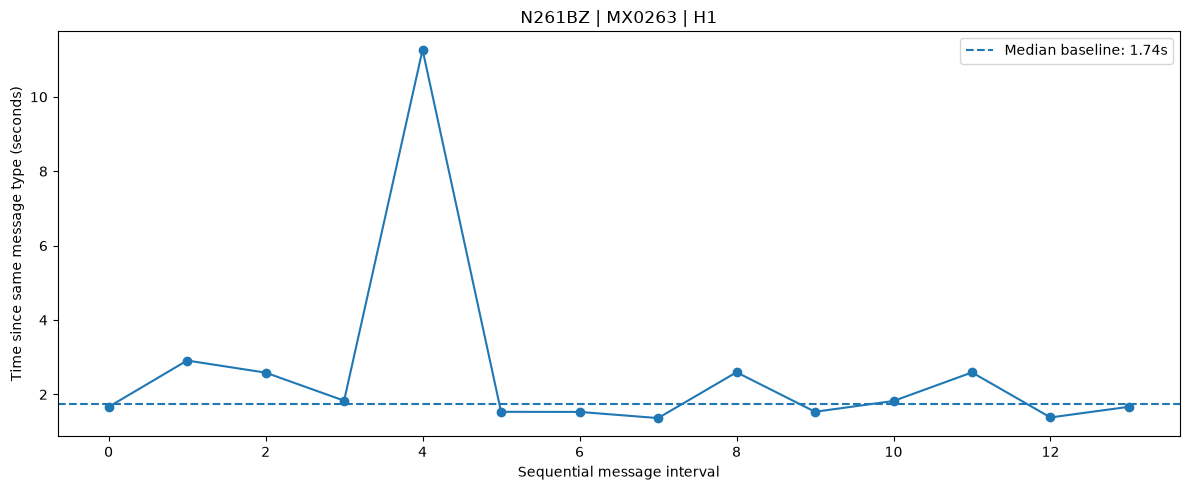

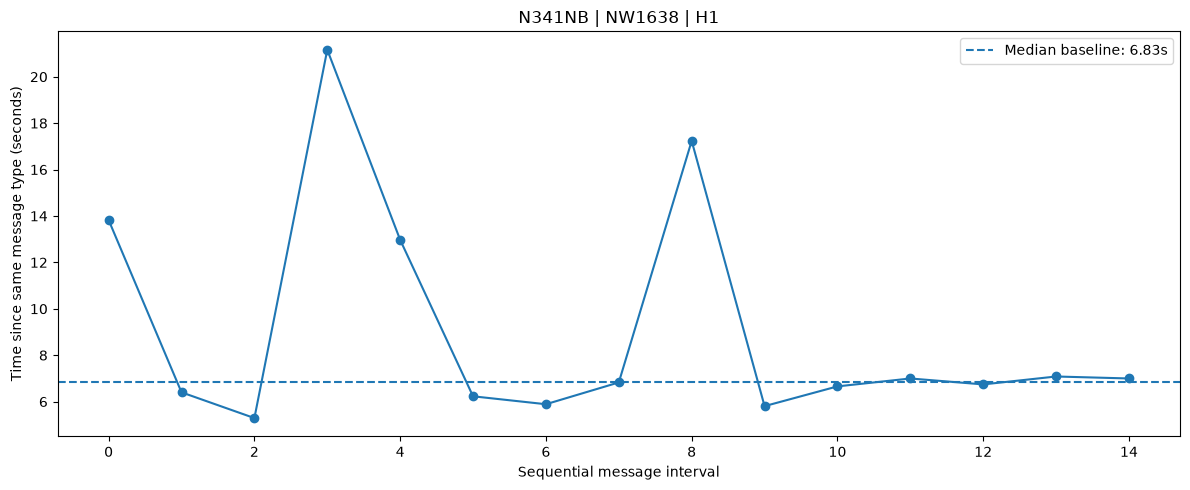

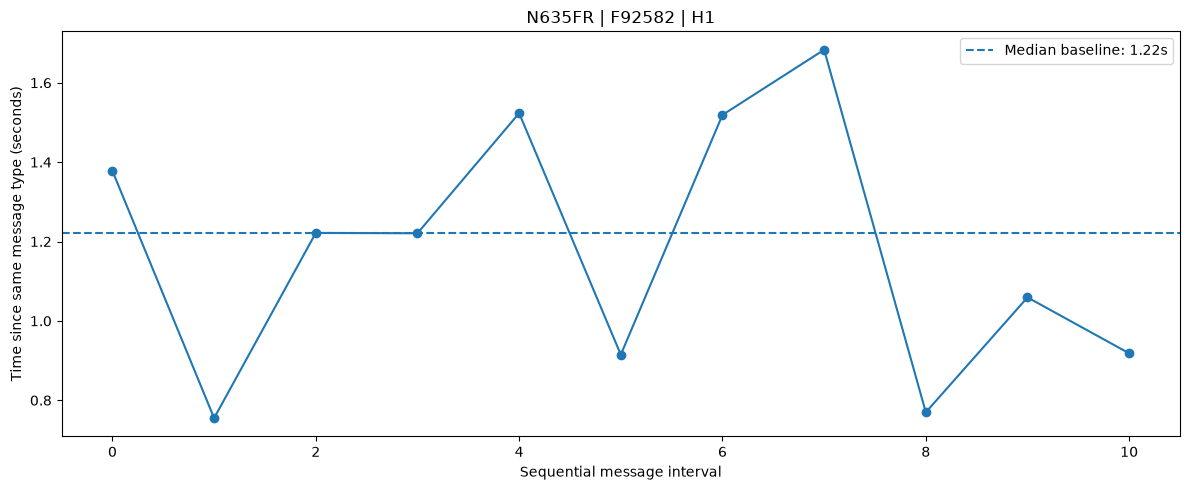

In [72]:
import matplotlib.pyplot as plt

eligible_keys = eligible_flights[
    ["registration", "flight_id", "message_type"]
]

plot_data = timing_scored.merge(
    eligible_keys,
    on=["registration", "flight_id", "message_type"],
    how="inner"
).dropna(subset=["time_since_same_type"])

plot_data = plot_data.sort_values(
    ["registration", "flight_id", "message_type", "timestamp"]
)

for (registration, flight_id, message_type), group in plot_data.groupby(
    ["registration", "flight_id", "message_type"]
):
    plt.figure(figsize=(12, 5))

    x = range(len(group))

    plt.plot(
        x,
        group["time_since_same_type"],
        marker="o"
    )

    baseline = group["median_interval"].iloc[0]

    plt.axhline(
        baseline,
        linestyle="--",
        label=f"Median baseline: {baseline:.2f}s"
    )

    plt.title(
        f"{registration} | {flight_id} | {message_type}"
    )

    plt.xlabel("Sequential message interval")
    plt.ylabel("Time since same message type (seconds)")

    plt.legend()
    plt.tight_layout()
    plt.show()

In [73]:
plot_data.shape

(40, 27)

In [74]:
eligible_flights

,registration,flight_id,message_type,scored_intervals,median_timing_deviation_score,max_timing_deviation_score,moderate_or_higher,high_or_higher,extreme
0,N261BZ,MX0263,H1,14,1.0,32.767865,2,1,1
3,N341NB,NW1638,H1,15,1.0,23.989818,4,4,4
6,N635FR,F92582,H1,11,1.0,1.539483,0,0,0


## 12. Protocol-Structure Table by Registration, Flight, and Label

Before interpreting the timing deviation scores above, this table restates the
protocol-structure check from Section 9 at the exact grouping used for
scoring: registration, flight, and ACARS label. For each stream it reports the
raw decoded-record count, the count of unique `msgNum` values, and the
observed time span in seconds.

Reading this table alongside the scored streams shows directly where a raw
record count diverges from a unique `msgNum` count, the signal that decoded
records in that stream may not each correspond to an independent logical
message.

In [75]:
protocol_structure_table = (
    timing_scored
    .groupby(["registration", "flight_id", "message_type"])
    .agg(
        raw_record_count=("timestamp", "size"),
        unique_msgnum_count=("msgNum", "nunique"),
        first_timestamp=("timestamp", "min"),
        last_timestamp=("timestamp", "max"),
    )
    .reset_index()
)

protocol_structure_table["span_seconds"] = (
    protocol_structure_table["last_timestamp"]
    - protocol_structure_table["first_timestamp"]
).dt.total_seconds()

protocol_structure_table = protocol_structure_table[
    [
        "registration",
        "flight_id",
        "message_type",
        "raw_record_count",
        "unique_msgnum_count",
        "span_seconds",
    ]
].sort_values("raw_record_count", ascending=False)

protocol_structure_table

,registration,flight_id,message_type,raw_record_count,unique_msgnum_count,span_seconds
5,N341NB,NW1638,H1,16,16,136.107079
0,N261BZ,MX0263,H1,15,2,36.253899
25,N635FR,F92582,H1,12,2,12.962883
16,N464UP,UP1333,H1,5,5,457.309267
1,N3307J,B62322,H1,3,2,7.923195
8,N378FR,F92959,H1,3,3,68.008014
28,N809VL,XP0223,H1,3,1,14.642584
2,N339PL,AA1246,H1,3,3,37.632836
6,N378FR,F92959,21,2,2,300.540490
9,N380FR,F92249,21,1,1,0.000000


## 13. Findings and Limitations

The exploratory analysis showed that robust timing statistics can surface large
deviations from a local baseline, but it also exposed a more fundamental
limitation: decoded records do not always represent independent logical
ACARS messages.

For example, N261BZ/MX0263 contains 15 decoded records but only 2 unique msgNum values, while N635FR/F92582 contains 12 records and 2 unique msgNum values. The current feature therefore measures decoded-record
timing, not consistently validated logical-message cadence.

The earlier methodology corrections were still important: the initial
baseline mixed different message cadences, and the first corrected scoring
pass retained stale baseline columns. Both issues were identified, corrected,
and re-run from a fresh kernel.

The current scores should therefore be treated as exploratory timing signals,
not evidence of malicious activity or anomalous aircraft behaviour.

A next iteration should reconstruct logical ACARS messages using protocol-aware
fields such as `msgNum` and `blockId` before evaluating inter-message timing.

### Limitations

This is a small exploratory sample with limited observation windows. The
current implementation does not perform logical-message reassembly and is not
a production detection.

Further work would require larger datasets, longer observation periods,
protocol-aware reconstruction, and validation against known benign and
malicious behaviour.

## 14. Interpretation

The timing deviation scores computed in this notebook identify large
deviations from a record-level timing baseline. On their own, they do not
establish anomalous or malicious behaviour: a high score means a decoded
record's timing was far from the local median for its stream, nothing more.

The protocol-structure table in Section 12 shows that for some streams
(for example N261BZ/MX0263 and N635FR/F92582), the raw record count
substantially exceeds the unique `msgNum` count. That gap indicates some of
the observations in this dataset may represent block spacing within a single
multi-block ACARS message rather than the cadence between distinct logical
messages. Where that is the case, a timing deviation score computed on
decoded records is measuring an artifact of message segmentation, not
message-to-message behaviour.

No threat model is defined for this feature. This notebook does not claim
that any identified deviation is evidence of spoofing, interference,
compromise, or any other adversarial behaviour, and no such claim should be
drawn from these scores without further protocol-aware validation.